# **Adversarial Search Strategies and Decision Trees**
### Unidade Curricular: Inteligência Artificial (CC2006)
### Ano Letivo 2025/2026

**Grupo 7 - PL6:** Gonçalo Sousa (202403669) / Guilherme Granjo (202404328) / Matilde Alves (202403407)
___

### **Índice**
1. Introdução
2. O Jogo PopOut
    - 2.1. Regras Especiais
    - 2.2. Implementação do Jogo
3. Monte Carlo Tree Search (MCTS)
    - 3.1. Implementação do Algoritmo
    - 3.2. Outras Estratégias de Implementação
        - 3.2.1. Interpretação de Resultados
    - 3.3. Criação do Dataset
4.  Árvores de Decisão (ID3)
    - 4.1. Aplicação ao Dataset *Iris*
        - 4.1.1. Interpretação de Resultados
    - 4.2. Aplicação ao Dataset *PopOut*
        - 4.2.1. Interpretação de Resultados
5. Execução do Jogo
6. Discussão Crítica de Resultados
7. Conclusão
8. Referências Bibliográficas

    ANEXO I

---
### **1. Introdução**
O presente projeto visa desenvolver e comparar duas abordagens de Inteligência Artificial aplicadas ao jogo de tabuleiro PopOut, nomeadamente a implementação do algoritmo Monte Carlo Tree Search (MCTS) com Upper Confidence Bound for Trees (UCT) e árvores de decisão através do procedimento ID3 (árvore de decisão supervisionada), aplicadas a dois conjuntos de dados distintos.

O objetivo é compreender praticamente o funcionamento e especificações de cada abordagem estudada, em concreto:
- Implementar o jogo PopOut com interface que suporte os modos *Humano vs. Humano*, *Humano vs. Computador* e *Computador vs. Computador*;
- Implementar o algoritmo MCTS com UCT como método de decisão;
- Explorar variantes do MCTS, tais como comparação de estratégias, número de simulações, constante de exploração e limitação de ramos;
- Implementar o algoritmo ID3 para construção de árvores de decisão;
- Aplicar o ID3 ao dataset Iris e ao dataset gerado pelo MCTS a partir de partidas do jogo PopOut;
- Avaliar e comparar criticamente o desempenho das soluções desenvolvidas.

---
### **2. O Jogo PopOut**
O jogo PopOut é uma variante do jogo de estratégia Connect-4, com a possibilidade de adicionar e remover jogadas, conferindo ao jogo uma complexidade estratégica superior. 

Tal como no Connect-4, dois jogadores colocam alternadamente peças da sua cor no topo de qualquer uma das 7 colunas (*drop*). A distinção fundamental do PopOut reside na existência de movimentos *pop*, em que um jogador pode remover uma das suas próprias peças da linha inferior do tabuleiro, fazendo com que todas as peças dessa coluna desçam uma posição.

O objetivo dos jogos mantém-se: ser o primeiro jogador a alinhar quatro peças da sua cor na horizontal, vertical ou diagonal.

#### **2.1. Regras Especiais**
O jogo PopOut define três regras adicionais para eliminar possíveis ambiguidades:
1. Vitória Simultânea: Se um movimento de *pop* criar 4-em-linha para ambos os jogadores, o jogador que executou o *pop* é o vencedor da partida;
2. Tabuleiro cheio: Se o tabuleiro estiver completamente preenchido, o jogador atual pode optar por realizar um *pop* ou declarar empate;
3. Regra da repetição: Se o mesmo estado do jogo se repetir 3 vezes, qualquer um dos jogadores pode declarar empate.


#### **2.2. Implementação do Jogo**
O jogo PopOut encontra-se implementado no ficheiro `popout.py`. O código encontra-se organizado em representações imutáveis do estado do jogo para ser possível explorar múltiplos cenários.

Importações e constantes:

In [4]:
# Execução fora do diretório /codes
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "codes").exists() and (PROJECT_ROOT.parent / "codes").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CODES_DIR = PROJECT_ROOT / "codes"
if str(CODES_DIR) not in sys.path:
    sys.path.insert(0, str(CODES_DIR))

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"CODES_DIR    = {CODES_DIR}")

PROJECT_ROOT = /home/matilde_wsl/IA_POPOUT
CODES_DIR    = /home/matilde_wsl/IA_POPOUT/codes


In [5]:
import numpy as np

ROWS, COLS = 6, 7
EMPTY, P1, P2 = 0, 1, 2
DIRECTIONS = [(0, 1), (1, 0), (1, 1), (1, -1)]
WINNER_DRAW = "draw"

A classe `Move` representa um movimento no jogo, nomeadamente uma coluna e o tipo de jogada (*drop* ou *pop*), com a respetiva validação de legibilidade.

In [6]:
class Move:
    def __init__(self, column, kind): #cria e inicializa o objeto
        if kind not in ("drop", "pop"):
            raise ValueError(f"invalid kind: {kind!r}")
        if not 0 <= column < COLS:
            raise ValueError(f"column out of [0,{COLS-1}]: {column}")
        self.column = column
        self.kind = kind

    def __eq__(self, other): #define a comparação com '=='
        if not isinstance(other, Move):
            return False
        return self.column == other.column and self.kind == other.kind

    def __hash__(self): #define o hash 
        return hash((self.column, self.kind))

    def __str__(self): #define a representação em string
        return f"{self.kind}({self.column})"

    def __repr__(self): #define a representação oficial
        return f"Move({self.column}, {self.kind!r})"

A classe `State` determina o estado imutável do jogo (estado base a cada nova jogada).

In [7]:
class State:
    def __init__(self, board, player_to_move, history_counts=None, last_move=None, winner=None):
        self.board = board # tabuleiro 6x7 com valores 0(vazio), 1(P1) e 2(P2)
        self.player_to_move = player_to_move # indicação do próximo jogador
        self.history_counts = history_counts if history_counts is not None else {} # deteção da tripla repetição de estados
        self.last_move = last_move # último movimento efetuado
        self.winner = winner # vencedor do jogo

A função `state_key` gera uma chave única para um par (tabuleiro, jogador) que será usada para detetar as repetições.

A função `initial_state` cria e desenvolve o estado inicial do jogo, com tabuleiro vazio e jogador P1 a começar.

A função `legal_moves` devolve todos os movimentos que o jogador pode executar.

In [8]:
def state_key(board, player_to_move):
    return board.tobytes() + bytes([player_to_move])


def initial_state():
    board = np.zeros((ROWS, COLS), dtype=np.int8)
    history = {state_key(board, P1): 1}
    return State(board=board, player_to_move=P1, history_counts=history)


def legal_moves(state):
    if state.winner is not None:
        return []
    moves = []
    for c in range(COLS):
        if state.board[0, c] == EMPTY:
            moves.append(Move(c, "drop"))
        if state.board[ROWS - 1, c] == state.player_to_move:
            moves.append(Move(c, "pop"))
    return moves

As funções `_drop_row`, `_four_in_a_row_for`, `_has_legal_pop` e `_has_legal_drop` verificam vitórias e jogadas possíveis:

In [9]:
# Devolve a linha mais baixa vazia na coluna c ou -1 se a coluna estiver cheia
def _drop_row(board, c):
    for r in range(ROWS - 1, -1, -1):
        if board[r, c] == EMPTY:
            return r
    return -1

# Verifica se o jogador tem 4-em-linha
def _four_in_a_row_for(board, player):
    for r in range(ROWS):
        for c in range(COLS):
            if board[r, c] != player:
                continue
            for dr, dc in DIRECTIONS:
                rr, cc = r + 3 * dr, c + 3 * dc
                if 0 <= rr < ROWS and 0 <= cc < COLS:
                    if all(board[r + i * dr, c + i * dc] == player for i in range(4)):
                        return True
    return False

# Retorna True se for possível o jogador realizar um pop
def _has_legal_pop(board, player):
    return bool((board[ROWS - 1, :] == player).any())

# Retorna True se for possível o jogador realizar um drop
def _has_legal_drop(board):
    return bool((board[0, :] == EMPTY).any())

A função `check_win` verifica se existe um vencedor após um movimento, de acordo com as regras especiais do PopOut.

In [10]:
def check_win(board, last_move, mover):
    other = 3 - mover
    me_won = _four_in_a_row_for(board, mover)
    other_won = _four_in_a_row_for(board, other)

    if last_move.kind == "pop":
        if me_won:
            return mover
        if other_won:
            return other
    else:
        if me_won:
            return mover

    next_player = 3 - mover
    if not _has_legal_drop(board) and not _has_legal_pop(board, next_player):
        return WINNER_DRAW
    return None

A função `apply_move` aplica o último movimento ao estado e devolve um novo estado imutável.

In [11]:
def apply_move(state, move):
    if state.winner is not None:
        raise ValueError("Game already finished.")

    new_board = state.board.copy()
    mover = state.player_to_move

    if move.kind == "drop":
        r = _drop_row(new_board, move.column)
        if r == -1:
            raise ValueError(f"Column {move.column} is full.")
        new_board[r, move.column] = mover
    else:
        if new_board[ROWS - 1, move.column] != mover:
            raise ValueError(f"Illegal pop on column {move.column}: bottom not player {mover}.")
        
        new_board[1:ROWS, move.column] = state.board[0:ROWS - 1, move.column]
        new_board[0, move.column] = EMPTY

    new_player = 3 - mover
    new_history = dict(state.history_counts)
    key = state_key(new_board, new_player)
    new_history[key] = new_history.get(key, 0) + 1

    winner = check_win(new_board, move, mover)

    return State(
        board=new_board,
        player_to_move=new_player,
        history_counts=new_history,
        last_move=move,
        winner=winner,
    )

As funções `can_claim_repetition_draw` e `render` determinam empate por repetição e reconfiguração do tabuleiro para o utilizador, respetivamente.

In [12]:
def can_claim_repetition_draw(state):
    key = state_key(state.board, state.player_to_move)
    return state.history_counts.get(key, 0) >= 3


def render(board):
    glyph = {EMPTY: "-", P1: "X", P2: "O"}
    lines = ["".join(glyph[int(v)] for v in row) for row in board]
    return "\n".join(lines)

---
### **3. Monte Carlo Tree Search (MCTS)**
O MCTS é um algoritmo de pesquisa heurística para tomada de decisões em grandes domínios de estados, como os jogos de tabuleiro, levando em consideração as constantes alterações causadas pelo adversário. A implementação utiliza o critério **Upper Confidence Bound for Trees (UCT)** para avaliar cada ramo da árvore, cuja fórmula é:

$$\text{UCT}(n) = \underbrace{\frac{U(n)}{N(n)}}_{\text{exploitation}} + C \cdot \underbrace{\sqrt{\frac{\ln N(\text{parent}(n))}{N(n)}}}_{\text{exploration}}$$
<span style="font-size: 0.9em;">

> **Notação UCT:** $n$ representa o nó a avaliar; $U(n)$ a utilidade acumulada; $N(n)$ o número de visitas ao nó $n$; $N_{parent(n)}$ o número de visitas ao nó pai de $n$; $C$ a constante de exploração.

</span>

A aplicação do algoritmo MCTS passa por 4 fases repetidas por $N$ iterações:
- **Selection:** A partir da raiz, escolhe o filho que maximiza o UCT até encontrar um nó não totalmente expandido;
- **Expansion:** Adiciona um nó filho ao nó selecionado, representando um estado ainda não explorado;
- **Simulation:** A partir do novo nó, executa um jogo até ao fim, através de uma simulação aleatória ou heurística *(rollout)*;
- **Backpropagation:** O resultado propaga-se de volta pelo percurso até à raíz, atualizando $N$ e $U$ em cada nó.

Ao fim das $N$ iterações, escolhe-se o filho com mais visitas.

#### **3.1. Implementação do Algoritmo**
O algoritmo MCTS encontra-se implementado no ficheiro `mcts.py`.

Importações e constrains:

In [13]:
import math
import random

from popout import COLS, Move, State, apply_move, legal_moves

DEFAULT_C = math.sqrt(2)
DEFAULT_N_SIMULATIONS = 500
ROLLOUT_MAX_DEPTH = 200

CENTER = COLS // 2
COLUMN_PRIORITY = sorted(range(COLS), key=lambda c: abs(c - CENTER))

A função `_ordered_legal_moves` devolve as jogadas possíveis por proximidade ao centro.  

In [14]:
def _ordered_legal_moves(state, max_children):
    moves = legal_moves(state)
    if max_children is None or len(moves) <= max_children:
        return moves
    drops = [m for m in moves if m.kind == "drop"]
    pops = [m for m in moves if m.kind == "pop"]
    drops.sort(key=lambda m: abs(m.column - CENTER))
    pops.sort(key=lambda m: abs(m.column - CENTER))
    return (drops + pops)[:max_children]

A classe `Node` armazena o estado do nó, estatísticas UCT e filhos.

In [15]:
class Node:
    def __init__(self, state, parent=None, move_in=None, max_children=None): #Inicializa o nó da árvore MCTS
        self.state = state
        self.parent = parent
        self.move_in = move_in
        self.children = {}
        self.untried_moves = list(_ordered_legal_moves(state, max_children))
        self.N = 0
        self.U = 0.0

    def is_terminal(self): #Devolve True se o estado for terminal
        return self.state.winner is not None

    def is_fully_expanded(self): #Devolve True se todas as jogadas possíveis já foram exploradas
        return len(self.untried_moves) == 0 and len(self.children) > 0

    def best_child(self, c): #Seleciona o filho com maior valor UCB1
        log_N_parent = math.log(self.N) if self.N > 0 else 0.0

        def ucb1(child):
            if child.N == 0:
                return math.inf
            exploit = child.U / child.N
            explore = c * math.sqrt(log_N_parent / child.N)
            return exploit + explore

        return max(self.children.values(), key=ucb1)

    def expand(self, rng, max_children=None): #Expande o nó
        idx = rng.randrange(len(self.untried_moves))
        move = self.untried_moves.pop(idx)
        next_state = apply_move(self.state, move)
        child = Node(next_state, parent=self, move_in=move, max_children=max_children)
        self.children[move] = child
        return child

    def most_visited_child(self): #Devolve o filho com maior número de visitas
        return max(self.children.values(), key=lambda c: c.N)

A função `_find_winning_move` devolve a primeira jogada que resulta em vitória imediata.

A função `_move_is_safe` verifica se a jogada é segura, ou seja, se o adversário não vence imediatamente.

In [16]:
def _find_winning_move(state, moves):
    me = state.player_to_move
    for m in moves:
        ns = apply_move(state, m)
        if ns.winner == me:
            return m
    return None

def _move_is_safe(state, m):
    ns = apply_move(state, m)
    if ns.winner is not None:
        return True
    opp = ns.player_to_move
    for om in legal_moves(ns):
        nns = apply_move(ns, om)
        if nns.winner == opp:
            return False
    return True

A função `find_forced_win` procura uma jogada que garanta vitória independentemente da jogada do adversário.

In [17]:
def find_forced_win(state, depth=2):
    if depth < 1 or state.winner is not None:
        return None

    me = state.player_to_move
    moves = legal_moves(state)

    win_now = _find_winning_move(state, moves)
    if win_now is not None:
        return win_now
    if depth == 1:
        return None

    for m in moves:
        ns = apply_move(state, m)
        if ns.winner == me:
            return m
        if ns.winner is not None:
            continue
        opp_moves = legal_moves(ns)
        if not opp_moves:
            continue
        all_lead_to_my_win = True
        for om in opp_moves:
            nns = apply_move(ns, om)
            if nns.winner == me:
                continue
            if nns.winner is not None:
                all_lead_to_my_win = False
                break
            if _find_winning_move(nns, legal_moves(nns)) is None:
                all_lead_to_my_win = False
                break
        if all_lead_to_my_win:
            return m
    return None

**Estratégias de *rollout***

O *rollout* é a simulação aleatória (ou semi-aleatória) que estima o valor de um nó. Foram implementadas três estratégias, nomeadamente:

- A função `random_playout`, que faz uma simulação aleatória de uma partida até que alguém ganhe, empate ou atinja determinada profundidade. Considerado custo baixo.

- A função `heuristic_win_playout`, que simula um jogo dando prioridade às vitorias imediatas, caso contrário, joga aleatoriamente. Considerado custo médio.

- A função `heuristic_block_playout` simula um jogo dando prioridade às vitórias imediatas e evita sempre a vitória do adversário. Considerado custo alto.

In [18]:
def random_playout(state, rng, max_depth=ROLLOUT_MAX_DEPTH):
    depth = 0
    while state.winner is None and depth < max_depth:
        moves = legal_moves(state)
        if not moves:
            return "draw"
        idx = rng.randrange(len(moves))
        state = apply_move(state, moves[idx])
        depth += 1
    return state.winner if state.winner is not None else "draw"

def heuristic_win_playout(state, rng, max_depth=ROLLOUT_MAX_DEPTH):
    depth = 0
    while state.winner is None and depth < max_depth:
        moves = legal_moves(state)
        if not moves:
            return "draw"
        winning = _find_winning_move(state, moves)
        chosen = winning if winning is not None else moves[rng.randrange(len(moves))]
        state = apply_move(state, chosen)
        depth += 1
    return state.winner if state.winner is not None else "draw"

def heuristic_block_playout(state, rng, max_depth=ROLLOUT_MAX_DEPTH):
    depth = 0
    while state.winner is None and depth < max_depth:
        moves = legal_moves(state)
        if not moves:
            return "draw"
        winning = _find_winning_move(state, moves)
        if winning is not None:
            state = apply_move(state, winning)
            depth += 1
            continue
        safe = [m for m in moves if _move_is_safe(state, m)]
        pool = safe if safe else moves
        chosen = pool[rng.randrange(len(pool))]
        state = apply_move(state, chosen)
        depth += 1
    return state.winner if state.winner is not None else "draw"


ROLLOUTS = {
    "random": random_playout,
    "heuristic_win": heuristic_win_playout,
    "heuristic_block": heuristic_block_playout,
}

A função `backprop` propaga o resultado, após o rollout, de volta até à raíz, atualizando $N$ e $U$.

In [19]:
def backprop(leaf, winner):
    node = leaf
    while node is not None:
        node.N += 1
        if node.parent is not None:
            chooser = node.parent.state.player_to_move
            if winner == chooser:
                node.U += 1.0
            elif winner == "draw":
                node.U += 0.5
        node = node.parent

A função `mcts_search` executa a implementação do algoritmo MCTS em si: realiza a pesquisa e devolve a melhor jogada a executar. 

A função `mcts_strategy` configura a função `mcts_search` e devolve uma função jogável.

In [20]:
def mcts_search(root_state, n_simulations=DEFAULT_N_SIMULATIONS, c=DEFAULT_C,
                rollout="random", max_children=None, tactical_root=False,
                tactical_depth=2, rng=None):

    if root_state.winner is not None:
        return None
    moves = legal_moves(root_state)
    if not moves:
        return None
    if len(moves) == 1:
        return moves[0]

    if tactical_root:
        forced = find_forced_win(root_state, depth=tactical_depth)
        if forced is not None:
            return forced

    if rollout not in ROLLOUTS:
        raise ValueError(f"invalid rollout: {rollout!r}. Choose from {list(ROLLOUTS)}.")
    playout_fn = ROLLOUTS[rollout]

    if rng is None:
        rng = random.Random()
    root = Node(root_state, max_children=max_children)

    for _ in range(n_simulations):
        node = root
        while node.is_fully_expanded() and not node.is_terminal():
            node = node.best_child(c)
        if not node.is_terminal():
            node = node.expand(rng, max_children=max_children)
        winner = playout_fn(node.state, rng)
        backprop(node, winner)

    return root.most_visited_child().move_in


def mcts_strategy(n_simulations=DEFAULT_N_SIMULATIONS, c=DEFAULT_C, rollout="random",
                  max_children=None, tactical_root=False, tactical_depth=2, rng=None):

    if rng is None:
        rng = random.Random()

    def strat(state):
        move = mcts_search(
            state,
            n_simulations=n_simulations,
            c=c,
            rollout=rollout,
            max_children=max_children,
            tactical_root=tactical_root,
            tactical_depth=tactical_depth,
            rng=rng,
        )
        if move is None:
            raise RuntimeError("mcts_strategy called on terminal state.")
        return move

    return strat

#### **3.2. Outras Estratégias de Implementação**
Para avaliar o impacto de diferentes configurações do MCTS, implementámos quatro variações estratégicas que se encontram no ficheiro `mcts_variations.py`:

|  | Ação | Valores testados |
|------|-----------|-----------------|
| **A** | Compara rollouts  | `random`, `heuristic_win`, `heuristic_block` |
| **B** | Avalia o impacto do número de simulações *N* no desempenho do MCTS | 100, 300, 600 |
| **C** | Avalia o impacto da constante de exploração *c* no desempenho do MCTS | 0.5, 1.0, √2, 2.0 |
| **D** | Avalia o impacto das limitações no *max_children* no desempenho do MCTS | None, 5, 3 |

Importações e constrains:

In [21]:
import argparse
import math
import random
import sys
import time

from game import play_game, random_strategy
from popout import P1, P2
from mcts import mcts_strategy

DEFAULT_C = math.sqrt(2)

A classe `MatchResult` armazena o resultado de jogo:

In [22]:
class MatchResult:
    def __init__(self, label_a, label_b, wins_a, wins_b, draws,
                 avg_time_a, avg_time_b, n_games):
        self.label_a = label_a
        self.label_b = label_b
        self.wins_a = wins_a
        self.wins_b = wins_b
        self.draws = draws
        self.avg_time_a = avg_time_a
        self.avg_time_b = avg_time_b
        self.n_games = n_games

A função `time_strategy` devolve o tempo gasto por jogada.

A função `run_match` executa partidas alterando o jogador que inicia a partida e devolve um `MatchResult` com as vitórias, empates e tempos médios por jogada.

In [23]:
def time_strategy(strat):
    times = []
    def wrapped(state):
        t0 = time.perf_counter()
        m = strat(state)
        times.append(time.perf_counter() - t0)
        return m
    wrapped._times = times
    return wrapped


def run_match(factory_a, factory_b, label_a, label_b,
              n_games=10, max_turns=300, seed_base=0):

    wins_a = 0
    wins_b = 0
    draws = 0
    times_a, times_b = [], []
    for g in range(n_games):
        if g % 2 == 0:
            sa = time_strategy(factory_a())
            sb = time_strategy(factory_b())
            p1, p2, a_player = sa, sb, P1
        else:
            sb = time_strategy(factory_b())
            sa = time_strategy(factory_a())
            p1, p2, a_player = sb, sa, P2
        final = play_game(p1, p2, on_render=lambda _: None,
                          show_intermediate=False, max_turns=max_turns)
        times_a.extend(sa._times)
        times_b.extend(sb._times)
        if final.winner == a_player:
            wins_a += 1
        elif final.winner == "draw":
            draws += 1
        else:
            wins_b += 1
    return MatchResult(
        label_a=label_a, label_b=label_b,
        wins_a=wins_a, wins_b=wins_b, draws=draws,
        avg_time_a=sum(times_a)/max(1, len(times_a)),
        avg_time_b=sum(times_b)/max(1, len(times_b)),
        n_games=n_games,
    )

As funções `factory_mcts` e `factory_random` retornam duas novas funções que criam, nomeadamente, uma estratégia MCTS e uma estratégia aleatória para inserção nos jogos.

In [24]:
def factory_mcts(n, c=DEFAULT_C, rollout="random", max_children=None, seed=None):
    def f():
        rng = random.Random(seed)
        return mcts_strategy(n_simulations=n, c=c, rollout=rollout,
                             max_children=max_children, rng=rng)
    return f

def factory_random(seed=None):
    def f():
        return random_strategy(random.Random(seed))
    return f

**Implementação das variações:**

In [25]:
def experiment_A(quick):
    n_games = 6 if quick else 10
    N = 200
    print(f"\n=== A: rollout (N={N}, {n_games} games) ===\n")
    matchups = [
        ("random", "heuristic_win"),
        ("random", "heuristic_block"),
        ("heuristic_win", "heuristic_block"),
    ]
    results = []
    for ra, rb in matchups:
        print(f"  {ra} vs {rb} ...", flush=True)
        r = run_match(
            factory_mcts(N, rollout=ra, seed=0),
            factory_mcts(N, rollout=rb, seed=1),
            label_a=ra, label_b=rb, n_games=n_games,
        )
        print(f"    A {r.wins_a} - {r.wins_b} B (draws {r.draws}) "
              f"| t/move A={r.avg_time_a*1000:.0f}ms B={r.avg_time_b*1000:.0f}ms")
        results.append(r)
    return results


def experiment_B(quick):
    n_games = 4 if quick else 8
    print(f"\n=== B: N (rollout=heuristic_win, {n_games} games) ===\n")
    matchups = [(100, 300), (300, 600), (300, "random_baseline")]
    results = []
    for a, b in matchups:
        if b == "random_baseline":
            la, lb = f"MCTS_N{a}_heur", "random"
            print(f"  {la} vs {lb} ...", flush=True)
            r = run_match(
                factory_mcts(a, rollout="heuristic_win", seed=0),
                factory_random(seed=999),
                label_a=la, label_b=lb, n_games=n_games,
            )
        else:
            la, lb = f"MCTS_N{a}", f"MCTS_N{b}"
            print(f"  {la} vs {lb} ...", flush=True)
            r = run_match(
                factory_mcts(a, rollout="heuristic_win", seed=0),
                factory_mcts(b, rollout="heuristic_win", seed=1),
                label_a=la, label_b=lb, n_games=n_games,
            )
        print(f"    A {r.wins_a} - {r.wins_b} B (draws {r.draws}) "
              f"| t/move A={r.avg_time_a*1000:.0f}ms B={r.avg_time_b*1000:.0f}ms")
        results.append(r)
    return results


def experiment_C(quick):
    n_games = 6 if quick else 12
    N = 200
    print(f"\n=== C: C (N={N}, vs random, {n_games} games) ===\n")
    cs = [0.5, 1.0, math.sqrt(2), 2.0]
    results = []
    for c in cs:
        la = f"MCTS_C{c:.2f}"
        print(f"  {la} vs random ...", flush=True)
        r = run_match(
            factory_mcts(N, c=c, rollout="heuristic_win", seed=0),
            factory_random(seed=999),
            label_a=la, label_b="random", n_games=n_games,
        )
        print(f"    {la} {r.wins_a} - {r.wins_b} random (draws {r.draws}) "
              f"| t/move {r.avg_time_a*1000:.0f}ms")
        results.append(r)
    return results


def experiment_D(quick):
    n_games = 4 if quick else 8
    N = 200
    print(f"\n=== D: max_children (N={N}, vs random, {n_games} games) ===\n")
    ks = [None, 5, 3]
    results = []
    for k in ks:
        la = f"MCTS_k{k}"
        print(f"  {la} vs random ...", flush=True)
        r = run_match(
            factory_mcts(N, rollout="heuristic_win", max_children=k, seed=0),
            factory_random(seed=999),
            label_a=la, label_b="random", n_games=n_games,
        )
        print(f"    {la} {r.wins_a} - {r.wins_b} random (draws {r.draws}) "
              f"| t/move {r.avg_time_a*1000:.0f}ms")
        results.append(r)
    return results

**Execução das variações:**

In [26]:
# Adaptação do código original para possível execução em notebook   
def print_table(title, results):
    print(f"\n## {title}\n")
    print(f"| {'A':<24} | {'B':<22} | A | B | D | t/A (ms) | t/B (ms) |")
    print(f"|{'-'*26}|{'-'*24}|---|---|---|----------|----------|")
    for r in results:
        print(f"| {r.label_a:<24} | {r.label_b:<22} | {r.wins_a} | {r.wins_b} | "
              f"{r.draws} | {r.avg_time_a*1000:>8.1f} | {r.avg_time_b*1000:>8.1f} |")


def main(argv=None):
    parser = argparse.ArgumentParser()
    parser.add_argument("--quick", action="store_true")
    parser.add_argument("--exp", choices=["A", "B", "C", "D"], default=None)
    if argv is None and "ipykernel" in sys.modules:
        args, _ = parser.parse_known_args()
    else:
        args = parser.parse_args(argv)

    t0 = time.time()
    all_results = {}
    if args.exp in (None, "A"):
        all_results["A"] = experiment_A(args.quick)
    if args.exp in (None, "B"):
        all_results["B"] = experiment_B(args.quick)
    if args.exp in (None, "C"):
        all_results["C"] = experiment_C(args.quick)
    if args.exp in (None, "D"):
        all_results["D"] = experiment_D(args.quick)
    elapsed = time.time() - t0

    print(f"\n\n{'='*70}\nSUMMARY ({elapsed:.0f}s total)\n{'='*70}")
    if "A" in all_results:
        print_table("A -- rollout", all_results["A"])
    if "B" in all_results:
        print_table("B -- N", all_results["B"])
    if "C" in all_results:
        print_table("C -- C", all_results["C"])
    if "D" in all_results:
        print_table("D -- max_children", all_results["D"])
    return 0

main()


=== A: rollout (N=200, 10 games) ===

  random vs heuristic_win ...
    A 0 - 10 B (draws 0) | t/move A=104ms B=254ms
  random vs heuristic_block ...
    A 10 - 0 B (draws 0) | t/move A=115ms B=8337ms
  heuristic_win vs heuristic_block ...
    A 0 - 10 B (draws 0) | t/move A=284ms B=8588ms

=== B: N (rollout=heuristic_win, 8 games) ===

  MCTS_N100 vs MCTS_N300 ...
    A 0 - 8 B (draws 0) | t/move A=117ms B=328ms
  MCTS_N300 vs MCTS_N600 ...
    A 0 - 8 B (draws 0) | t/move A=511ms B=1012ms
  MCTS_N300_heur vs random ...
    A 8 - 0 B (draws 0) | t/move A=307ms B=0ms

=== C: C (N=200, vs random, 12 games) ===

  MCTS_C0.50 vs random ...
    MCTS_C0.50 12 - 0 random (draws 0) | t/move 292ms
  MCTS_C1.00 vs random ...
    MCTS_C1.00 12 - 0 random (draws 0) | t/move 270ms
  MCTS_C1.41 vs random ...
    MCTS_C1.41 12 - 0 random (draws 0) | t/move 220ms
  MCTS_C2.00 vs random ...
    MCTS_C2.00 12 - 0 random (draws 0) | t/move 348ms

=== D: max_children (N=200, vs random, 8 games) ===

  M

0

#### **3.2.1 Interpretação de Resultados**

**A - Alterações na estratégia de *rollout* implementada**

Na comparação entre *rollouts*, é possível observar uma relação clara entre as vantagens do tipo de decisão e o custo computacional. 

A estratégia `heuristic_win` ganha a `random` por ser uma estratégia que obtém consistentemente estados terminais favoráveis. A estratégia `random` ganha a `heuristic_block`, uma vez que, por o custo computacional ser tão elevado, o *random* executa muitas mais simulações no mesmo orçamento de tempo, compensando a menor qualidade individual de cada um. No entanto, este resultado não deixa de ser um paradoxo. A estratégia `heuristic_block` ganha a `heuristic_win` por evitar sistematicamente derrotass imediatas, produzindo estimativas mais robustas.

**Conclusão:** Apesar do `heuristic_block` ser estrategicamente mais completo, o `heuristic_win` possui a melhora relação qualidade/custo.

---
**B - Alterações no número de simulações $N$**

É possível concluir institivamente que mais simulações produzem sempre um jogador mais forte, uma vez que $N$=300 ganha a $N$=100 e $N$=600 ganha a $N$=300. Numa abordagem $N$=300 com `heuristic_win`, esta vence sempre a estratégia aleatória.

Outro parâmetro a notar é o custo: alterar $N$ altera proporcionalmente o tempo por jogada, pelo que a escolha de $N$ envolve sempre um compromisso tempo/qualidade.

**Conclusão:** `heuristic_win` com $N$=200-300 aparenta ser a melhor opção.

---
**C - Alterações na constante de exploração $C$**

Todos os valores de $C$ testados *(0.5, 1.0, √2, 2.0)* vencem a estratégia aleatória. Isto indica que, contra uma estratégia aleatória, o MCTS com $N$=200 é suficiente para qualquer valor razoável de $C$. 

Em teoria, $C$ mais alto favorece *exploration* (experimenta mais jogadas diferentes), enquanto que $C$ mais baixo favorece *exploitation* (aprofunda as melhores jogadas já conhecidas). Desta forma, para distinguir o impacto de $C$ seria necessário testar *MCTS vs. MCTS* com diferentes valores da constante de exploração.

**Conclusão:** $C$ = $\sqrt{2}$ (valor teórico) retorna o melhor resultado.

---
**D - Alterações no número de ramos explorados *(max_children)***

Limitar o número de ramos explorados por nó reduz significativamente o tempo necessário por jogada. Todos os valores vencem o adversário aleatório em 100% dos jogos, sugerindo que a limitação a 3–5 colunas centrais não perde qualidade relevante contra oponentes fracos. A ordenação por proximidade ao centro (implementada em `_ordered_legal_moves`) garante que as melhores jogadas são preservadas.

Assim, para $N$ fixo, *max_children* reduz a largura da árvore e concentra as simulações em menos ramos — mais profundidade por ramo, menos diversidade.

**Conclusão:** *max_children* = 5 mantem o equilíbrio entre tempo e diversidade de colunas centrais.

---

#### **3.3. Criação do Dataset**

Para treinar uma árvore de decisão no domínio do PopOut, foi criado um dataset de pares **(estado, jogada)** a partir de partidas simuladas com MCTS.

Cada exemplo representa um estado completo do tabuleiro (42 células + jogador a jogar = 43 features) e a jogada que o MCTS escolheu nesse estado.
A geração encontra-se implementada no ficheiro `generate_dataset.py` e produz o ficheiro `popout_dataset.csv`.

Importações necessárias:

In [27]:
import argparse
import csv
import math
import os
import random
import sys
import time

from popout import COLS, Move, apply_move, initial_state, legal_moves
from mcts import mcts_strategy

As funções `encode_move`, `encode_state_row`, `feature_columns` e `write_header` codificam e estruturam os dados do jogo para serem inseridos no arquivo cvs.

In [28]:
# Codificação de jogadas (ex.: 'd3' para drop - coluna 3, 'p0' para pop - coluna 0)
def encode_move(move):
    return f"{'d' if move.kind == 'drop' else 'p'}{move.column}"

# Codificação de estados numa lista de inteiros
def encode_state_row(state):
    flat = state.board.reshape(-1).tolist()
    return [int(v) for v in flat] + [int(state.player_to_move)]

# Devolve a lista dos nomes das colunas
def feature_columns():
    return [f"s{i}" for i in range(42)] + ["to_play"]

# Escreve a linha de cabeçalho (nomes das colunas) no CSV.
def write_header(writer):
    writer.writerow(feature_columns() + ["move"])


A função `generate_dataset` cria um dataset de pares (estado, movimento) a partir do jogo PopOut com o algoritmo MCTS.

In [29]:
def generate_dataset(n_games=50, out_path="popout_dataset.csv", epsilon=0.10, n_simulations=200, rollout="heuristic_win", tactical_root=True,
                     c=math.sqrt(2), seed=0, max_turns=300, verbose=True):
    
    if os.path.dirname(out_path):
        os.makedirs(os.path.dirname(out_path), exist_ok=True)

    rng_master = random.Random(seed)
    n_pairs = 0
    n_random_moves = 0
    n_mcts_moves = 0
    n_pops = 0
    game_lengths = []
    winners = {1: 0, 2: 0, "draw": 0, "incomplete": 0}
    move_class_counts = {}
    t0 = time.time()

    with open(out_path, "w", newline="") as f:
        writer = csv.writer(f)
        write_header(writer)

        for g in range(n_games):
            state = initial_state()
            game_seed = rng_master.randint(0, 10**9)
            rng_game = random.Random(game_seed)
            mcts = mcts_strategy(
                n_simulations=n_simulations, c=c,
                rollout=rollout, tactical_root=tactical_root,
                rng=random.Random(game_seed + 1),
            )

            turns = 0
            while state.winner is None and turns < max_turns:
                legal = legal_moves(state)
                if not legal:
                    break
                if rng_game.random() < epsilon:
                    move = legal[rng_game.randrange(len(legal))]
                    n_random_moves += 1
                else:
                    move = mcts(state)
                    n_mcts_moves += 1

                writer.writerow(encode_state_row(state) + [encode_move(move)])
                n_pairs += 1
                cls = encode_move(move)
                move_class_counts[cls] = move_class_counts.get(cls, 0) + 1
                if move.kind == "pop":
                    n_pops += 1

                state = apply_move(state, move)
                turns += 1

            game_lengths.append(turns)
            if state.winner in (1, 2):
                winners[state.winner] += 1
            elif state.winner == "draw":
                winners["draw"] += 1
            else:
                winners["incomplete"] += 1

            if verbose and (g + 1) % max(1, n_games // 10) == 0:
                elapsed = time.time() - t0
                rate = (g + 1) / elapsed
                eta = (n_games - g - 1) / rate if rate > 0 else 0
                print(f"  game {g+1}/{n_games}  pairs={n_pairs}  "
                      f"{elapsed:.0f}s elapsed  ETA {eta:.0f}s", flush=True)

    elapsed = time.time() - t0
    csv_size = os.path.getsize(out_path)
    return {
        "n_games": n_games, "n_pairs": n_pairs,
        "n_mcts_moves": n_mcts_moves, "n_random_moves": n_random_moves,
        "n_pops": n_pops, "pop_rate": n_pops / max(1, n_pairs),
        "epsilon": epsilon, "winners": winners,
        "avg_game_length": sum(game_lengths) / max(1, len(game_lengths)),
        "min_game_length": min(game_lengths) if game_lengths else 0,
        "max_game_length": max(game_lengths) if game_lengths else 0,
        "elapsed_s": elapsed, "csv_path": out_path, "csv_bytes": csv_size,
        "move_class_counts": dict(
            sorted(move_class_counts.items(), key=lambda kv: -kv[1])
        ),
    }

# Função main adaptada para possível execução no notebook
def main(out_path="popout_dataset.csv", n_games=50, epsilon=0.10, n_simulations=200, 
         rollout="heuristic_win", tactical=True, seed=0):
    print("=== Generate PopOut dataset ===")
    print(f"games={n_games} eps={epsilon} N={n_simulations} "
          f"rollout={rollout} tactical={tactical} seed={seed}\n")
    stats = generate_dataset(
        n_games=n_games, out_path=out_path, epsilon=epsilon,
        n_simulations=n_simulations, rollout=rollout,
        tactical_root=tactical, seed=seed,
    )
    print(f"\nPairs:        {stats['n_pairs']}  (mcts={stats['n_mcts_moves']} "
          f"random={stats['n_random_moves']})")
    print(f"Pops:         {stats['n_pops']} ({stats['pop_rate']*100:.1f}%)")
    print(f"Winners:      P1={stats['winners'][1]} P2={stats['winners'][2]} "
          f"draw={stats['winners']['draw']} incomplete={stats['winners']['incomplete']}")
    print(f"Game length:  avg {stats['avg_game_length']:.1f} plies "
          f"(min={stats['min_game_length']} max={stats['max_game_length']})")
    print(f"Time:         {stats['elapsed_s']:.1f}s")
    print(f"CSV:          {stats['csv_path']}  ({stats['csv_bytes']/1024:.1f} KB)")
    print("\nTop classes:")
    for cls, n in list(stats["move_class_counts"].items())[:8]:
        print(f"  {cls}: {n} ({n/stats['n_pairs']*100:.1f}%)")


# Execução da função com os mesmos parâmetros do código original
main(n_games=50, n_simulations=200)

=== Generate PopOut dataset ===
games=50 eps=0.1 N=200 rollout=heuristic_win tactical=True seed=0

  game 5/50  pairs=58  13s elapsed  ETA 121s
  game 10/50  pairs=158  37s elapsed  ETA 149s
  game 15/50  pairs=242  60s elapsed  ETA 140s
  game 20/50  pairs=329  82s elapsed  ETA 123s
  game 25/50  pairs=429  102s elapsed  ETA 102s
  game 30/50  pairs=504  121s elapsed  ETA 81s
  game 35/50  pairs=626  152s elapsed  ETA 65s
  game 40/50  pairs=684  167s elapsed  ETA 42s
  game 45/50  pairs=768  184s elapsed  ETA 20s
  game 50/50  pairs=856  209s elapsed  ETA 0s

Pairs:        856  (mcts=779 random=77)
Pops:         41 (4.8%)
Winners:      P1=33 P2=17 draw=0 incomplete=0
Game length:  avg 17.1 plies (min=7 max=34)
Time:         209.5s
CSV:          popout_dataset.csv  (75.4 KB)

Top classes:
  d3: 182 (21.3%)
  d4: 152 (17.8%)
  d2: 140 (16.4%)
  d5: 110 (12.9%)
  d1: 103 (12.0%)
  d6: 75 (8.8%)
  d0: 53 (6.2%)
  p3: 10 (1.2%)


**Análise do Dataset:**

**Distribuição de classes:** O MCTS mostra uma forte preferência pelas colunas centrais: a coluna 3 tem prevalência de escolha em todas as jogadas, e as 4 colunas centrais (1–5) representam em conjunto ~80% do total. É possível compreender estes resultados, uma vez que as colunas centrais controlam mais diagonais e horizontais, e portanto são estrategicamente mais fortes.

**Baixa taxa de pops:** Os movimentos *pop* são raros porque o MCTS só os utiliza quando são vantajosos. Assim, fazer *drop* numa posição central é é uma preferência no decorrer do jogo. 

**Média de ~17 jogadas:** As partidas MCTS são relativamente curtas, indicando que o algoritmo encontra vitórias rapidamente quando ambos os jogadores usam heurísticas táticas.

---
### **4. Árvores de Decisão (ID3)**

O algoritmo ID3 *(Iterative Dichotomiser 3)* constrói recursivamente uma árvore de decisão, escolhendo em cada nó o atributo que maximiza o ganho de informação (redução esperada da entropia após a divisão).

O algoritmo encontra-se implementado no ficheiro `decision_tree_builder.py`.

Importações necessárias:

In [30]:
import math
import re
from collections import Counter

import numpy as np
import pandas as pd

A classe `Node` representa um nó da árvore de decisão ID3, que pode ser de dois tipos: nó interno (feature - atributo de separação // filhos) ou folha (label - classe prevista).

In [31]:
class Node:
    def __init__(self, feature=None, children=None, label=None, n_samples=0, class_counts=None):
        self.feature = feature
        self.children = children if children is not None else {}
        self.label = label
        self.n_samples = n_samples
        self.class_counts = class_counts if class_counts is not None else {}

    @property
    def is_leaf(self):
        return self.label is not None

    def __repr__(self):
        if self.is_leaf:
            return f"Leaf(label={self.label!r}, n={self.n_samples})"
        return f"Node(feature={self.feature!r}, |children|={len(self.children)})"

A função `entropy` calcula a entropia da sequência de labels $y$, pela fórmula:

$$H(Y) = \sum_i - P({y_i}) \log_2 P({y_i})$$

In [32]:
def entropy(y):
    if len(y) == 0:
        return 0.0
    counts = Counter(y)
    total = len(y)
    return -sum((c / total) * math.log2(c / total) for c in counts.values() if c)

A função `information_gain` calcula o ganho de informação de dividir X e Y pela feature especificada, pela fórmula:

$$\text{IG}(X) = H(Y) - \sum_j \frac{|S_j|}{|S|} H(Y \mid X=j)$$

In [33]:
# X: DataFrame de atributos, y: Series de rótulos, feature: nome da coluna de X a avaliar

def information_gain(X, y, feature):
    base = entropy(y)
    total = len(y)
    if total == 0:
        return 0.0
    cond = 0.0
    for value in X[feature].unique():
        sub_y = y[X[feature] == value]
        if len(sub_y):
            cond += (len(sub_y) / total) * entropy(sub_y)
    return base - cond

A função principal `id3` cria recursivamente a árvore de decisão ID3 que retorna o nó raíz da árvore de decisão.

In [34]:
def id3(X, y, features, parent_majority=None, max_depth=None, depth=0):
    counts = dict(Counter(y))
    n_samples = len(y)

    # Subconjunto vazio -> usa a classe maioritaria do pai
    if n_samples == 0:
        return Node(label=parent_majority, n_samples=0)

    # Subconjunto puro -> folha com essa classe
    if len(counts) == 1:
        only_class = next(iter(counts))
        return Node(label=only_class, n_samples=n_samples, class_counts=counts)

    # Sem features (ou limite de profundidade) -> folha pela maioria
    if not features or (max_depth is not None and depth >= max_depth):
        majority = max(counts.items(), key=lambda kv: kv[1])[0]
        return Node(label=majority, n_samples=n_samples, class_counts=counts)

    gains = [(f, information_gain(X, y, f)) for f in features]
    best_feature, best_gain = max(gains, key=lambda x: x[1])

    # Nenhum atributo separa nada: ruido/ambiguidade -> folha pela maioria
    if best_gain <= 0:
        majority = max(counts.items(), key=lambda kv: kv[1])[0]
        return Node(label=majority, n_samples=n_samples, class_counts=counts)

    node = Node(feature=best_feature, n_samples=n_samples, class_counts=counts)
    majority = max(counts.items(), key=lambda kv: kv[1])[0]
    remaining = [f for f in features if f != best_feature]

    for value in sorted(X[best_feature].unique(), key=str):
        mask = X[best_feature] == value
        node.children[value] = id3(
            X[mask], y[mask], remaining,
            parent_majority=majority,
            max_depth=max_depth,
            depth=depth + 1,
        )
    return node

As seguintes funções são responsáveis por inferir e avaliar resultados do uso da árvore, nomeadamente:
- `predict` tem como função prever a classe de um único exemplo, ou seja, percorre a árvore como um fluxo de decisões até obter a classe final;
- `predict_batch` prevê todos os exemplos do DataFrame e devolve uma lista de labels, de uma só vez;
- `accuracy` avalia a qualidade das previsões realizadas nas funções anteriores;
- `_majority_label` devolve a label com maior contagem total entre as folhas descendentes de um nó.

In [35]:
def predict(tree, sample):
    node = tree
    while not node.is_leaf:
        value = sample.get(node.feature)
        if value in node.children:
            node = node.children[value]
        else:
            # Valor nunca visto neste no: vota entre as folhas descendentes
            return _majority_label(node)
    return node.label

def predict_batch(tree, X):
    return [predict(tree, row.to_dict()) for _, row in X.iterrows()]

def accuracy(y_true, y_pred):
    y_true = list(y_true)
    y_pred = list(y_pred)
    if not y_true:
        return 0.0
    return sum(1 for a, b in zip(y_true, y_pred) if a == b) / len(y_true)

def _majority_label(node):
    if node.is_leaf:
        return node.label
    counts = Counter()
    stack = [node]
    while stack:
        n = stack.pop()
        if n.is_leaf:
            counts[n.label] += n.n_samples
        else:
            stack.extend(n.children.values())
    if not counts:
        return None
    return max(counts.items(), key=lambda kv: kv[1])[0]

Para que a árvore de decisão consiga fazer divisões mais interpretáveis, e uma vez que o algoritgmo ID3 funciona de forma mais estável com atributos categóricos, é necessária a **discretização** de valores numéricos em categorias.

A classe `DiscretizationFit` armazena parâmetros do discretizador, tais como a estratégia de discretização *(por largura, frequência ou corte escolhido pelo ganho de informação)*, limites para cada coluna e o nome dos valores categóricos finais a serem usados pelo ID3.

As funções abaixo da classe permitem a distinção entre as diferentes estratégias a aplicar ao discretizador.

A última função `transform_discretizer` substitui os valores numéricos por labels.

In [36]:
class DiscretizationFit:
    def __init__(self, strategy, edges, labels):
        self.strategy = strategy
        self.edges = edges
        self.labels = labels

# Ajusta o discretizador por largura igual
def fit_discretizer_equal_width(X, columns, n_bins=3):
    edges, labels = {}, {}
    for col in columns:
        col_min, col_max = float(X[col].min()), float(X[col].max())
        if col_min == col_max:
            edges[col] = np.array([col_min, col_max])
            labels[col] = ["bin0"]
            continue
        edges[col] = np.linspace(col_min, col_max, n_bins + 1)
        labels[col] = [f"bin{i}" for i in range(n_bins)]
    return DiscretizationFit("equal_width", edges, labels)

# Ajusta o discretizador por frequência igual
def fit_discretizer_equal_frequency(X, columns, n_bins=3):
    edges, labels = {}, {}
    for col in columns:
        quantiles = np.linspace(0, 1, n_bins + 1)
        e = np.unique(np.quantile(X[col].values, quantiles))
        edges[col] = e
        labels[col] = [f"bin{i}" for i in range(len(e) - 1)]
    return DiscretizationFit("equal_frequency", edges, labels)

# Ajusta o discretizador por ganho de informação
def fit_discretizer_supervised(X, y, columns):
    edges, labels = {}, {}
    for col in columns:
        values = X[col].values
        sorted_vals = np.sort(np.unique(values))
        candidates = (sorted_vals[:-1] + sorted_vals[1:]) / 2
        base_h = entropy(y)
        n = len(y)
        best_t = None
        best_gain = -1.0
        for t in candidates:
            left, right = y[values <= t], y[values > t]
            if len(left) == 0 or len(right) == 0:
                continue
            cond = (len(left) / n) * entropy(left) + (len(right) / n) * entropy(right)
            gain = base_h - cond
            if gain > best_gain:
                best_gain = gain
                best_t = float(t)
        if best_t is None:
            best_t = float(np.median(values))
        edges[col] = np.array([-np.inf, best_t, np.inf])
        labels[col] = ["low", "high"]
    return DiscretizationFit("supervised", edges, labels)

def transform_discretizer(X, fit):
    out = X.copy()
    for col, e in fit.edges.items():
        if col not in out.columns:
            continue
        bins = np.searchsorted(e, out[col].values, side="right") - 1
        bins = np.clip(bins, 0, len(fit.labels[col]) - 1)
        out[col] = [fit.labels[col][i] for i in bins]
    return out


#### **4.1 Aplicação ao Dataset `Iris`**

Para testar o algoritmo ID3, foi utilizado o dataset `iris.cvs` fornecido, de forma a treinar uma árvore decisão que, dadas quatro características (comprimento da sépala, largura da sépala, comprimento da pétala e largura da pétala), consiga determinar a que espécie cada planta pertence (*Iris setosa*, *Iris versicolor* e *Iris virginica*).

Importações necessárias:

In [ ]:
# Código adaptado para possível execução no notebook
import os
import sys
from pathlib import Path

if "CODES_DIR" in globals():
    base_dir = Path(CODES_DIR)
else:
    cwd = Path.cwd()
    base_dir = cwd / "codes" if (cwd / "codes").exists() else cwd

if str(base_dir) not in sys.path:
    sys.path.insert(0, str(base_dir))

if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")

import argparse

import numpy as np
import pandas as pd

from decision_tree_builder import (
    accuracy,
    fit_discretizer_equal_frequency,
    fit_discretizer_equal_width,
    fit_discretizer_supervised,
    id3,
    predict_batch,
    render_tree_matplotlib,
    render_tree_text,
    transform_discretizer,
    tree_size,
)

IRIS_PATH = str(base_dir / "iris" / "iris.csv")

A função `load_iris` carrega o dataset, remove a coluna "ID" *(informação desnecessária para a árvore)* e separa as features da classe.

In [ ]:
# Código adaptado para possível execução no notebook
def load_iris():
    if "IRIS_PATH" in globals():
        iris_path = IRIS_PATH
    else:
        base_dir = str(CODES_DIR) if "CODES_DIR" in globals() else str(Path.cwd() / "codes")
        iris_path = os.path.join(base_dir, "iris", "iris.csv")
        if not os.path.exists(iris_path):
            iris_path = os.path.join(base_dir, "docs", "iris (2).csv")
    df = pd.read_csv(iris_path).drop(columns=["ID"])
    feats = [c for c in df.columns if c != "class"]
    return df[feats], df["class"], feats

As próximas funções preparam e avaliam dados para treino e teste:
- `split` divide os dados de forma aleatória em partições de treino e teste;
- `confusion_matrix` calcula uma matriz que traduza os acertos e os erros por classe;
- `kfold_indices` cria os índices para validação cruzada k-fold *(técnica de validação para avaliar melhor um modelo)*.

In [38]:
def split(X, y, frac_train=0.8, seed=0):
    df = X.copy()
    df["__y"] = y.values
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    sp = int(frac_train * len(df))
    train, test = df.iloc[:sp], df.iloc[sp:]
    feats = [c for c in df.columns if c != "__y"]
    return train[feats], train["__y"], test[feats], test["__y"]


def confusion_matrix(y_true, y_pred, classes=None):
    if classes is None:
        classes = sorted(set(list(y_true) + list(y_pred)))
    idx = {c: i for i, c in enumerate(classes)}
    M = np.zeros((len(classes), len(classes)), dtype=int)
    for a, b in zip(y_true, y_pred):
        M[idx[a], idx[b]] += 1
    return classes, M


def kfold_indices(n, k, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(n)
    rng.shuffle(idx)
    folds = np.array_split(idx, k)
    out = []
    for i in range(k):
        test = folds[i]
        train = np.concatenate([folds[j] for j in range(k) if j != i])
        out.append((train, test))
    return out

As funções `evaluate` e `kfold_eval` avaliam o desempenho da combinação discretização + ID3 em diferentes contextos: na partição treino/teste e na validação cruzada k-fold, respetivamente.

In [39]:
def evaluate(name, fit_fn, X_tr, y_tr, X_te, y_te, feats):
    fit = fit_fn(X_tr, y_tr, feats)
    Xtrd = transform_discretizer(X_tr, fit)
    Xted = transform_discretizer(X_te, fit)
    tree = id3(Xtrd, y_tr, feats)
    a_tr = accuracy(y_tr, predict_batch(tree, Xtrd))
    a_te = accuracy(y_te, predict_batch(tree, Xted))
    sz = tree_size(tree)
    return {
        "name": name, "tree": tree, "fit": fit,
        "acc_train": a_tr, "acc_test": a_te,
        "size": sz, "y_pred_test": predict_batch(tree, Xted),
    }


def kfold_eval(X, y, feats, fit_fn_factory, k=5, seed=0):
    accs, sizes = [], []
    for train_idx, test_idx in kfold_indices(len(X), k, seed=seed):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_te, y_te = X.iloc[test_idx], y.iloc[test_idx]
        fit = fit_fn_factory(X_tr, y_tr, feats)
        Xtrd = transform_discretizer(X_tr, fit)
        Xted = transform_discretizer(X_te, fit)
        tree = id3(Xtrd, y_tr, feats)
        accs.append(accuracy(y_te, predict_batch(tree, Xted)))
        sizes.append(tree_size(tree)["leaves"])
    return {
        "mean_acc": float(np.mean(accs)), "std_acc": float(np.std(accs)),
        "mean_leaves": float(np.mean(sizes)), "accs": accs,
    }

=== Iris ===
Dataset: 150 examples, classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

--- Discretisation strategies (split 80/20, seed=0) ---
strategy                      tr     te   leaves  depth
supervised (binary)       0.717  0.633      4      3
equal_width(k=3)          0.992  0.933      5      3
equal_width(k=5)          0.967  0.900     17      4
equal_frequency(k=3)      0.992  0.933     10      4

--- 5-fold cross-validation ---
strategy                    mean_acc    std_acc   mean_leaves
supervised (binary)            0.653      0.072           4.2
equal_width(k=3)               0.947      0.040           8.4
equal_frequency(k=3)           0.947      0.045          12.6

Best strategy by test accuracy: equal_width(k=3)

--- Confusion matrix ---
classes = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
[[10  0  0]
 [ 0  9  2]
 [ 0  0  9]]

--- Tree (text) ---
petalwidth? (n=120)
   └─ [bin0] class: Iris-setosa (n=40) {'Iris-setosa': 40}
   └─ [bin1] petalle

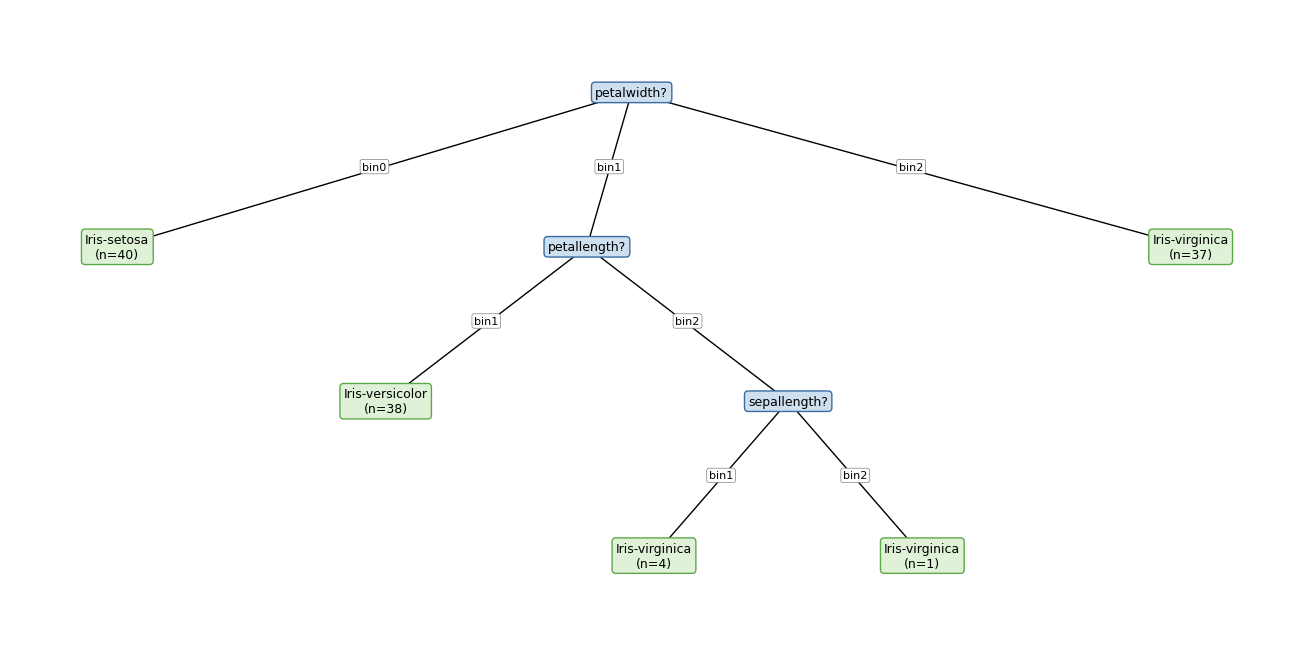

In [ ]:
# Avalia estratégias de discretização e guarda resultados
# Código adaptado para possível execução no notebook
def main(argv=None):
    parser = argparse.ArgumentParser()
    parser.add_argument("--out-dir", default="content")
    parser.add_argument("--quick", action="store_true")
    if argv is None and "ipykernel" in sys.modules:
        args, _ = parser.parse_known_args()
    else:
        args = parser.parse_args(argv)

    if "CODES_DIR" in globals():
        base_dir = str(CODES_DIR)
    else:
        cwd = os.getcwd()
        base_dir = os.path.join(cwd, "codes") if os.path.exists(os.path.join(cwd, "codes")) else cwd

    out_dir = os.path.join(base_dir, args.out_dir)
    os.makedirs(out_dir, exist_ok=True)

    print("=== Iris ===")
    X, y, feats = load_iris()
    print(f"Dataset: {len(X)} examples, classes: {sorted(y.unique())}\n")

    print("--- Discretisation strategies (split 80/20, seed=0) ---")
    print(f"{'strategy':<25} {'tr':>6} {'te':>6} {'leaves':>8} {'depth':>6}")
    X_tr, y_tr, X_te, y_te = split(X, y, seed=0)
    strategies = [
        ("supervised (binary)",
         lambda x, t, f: fit_discretizer_supervised(x, t, f)),
        ("equal_width(k=3)",
         lambda x, t, f: fit_discretizer_equal_width(x, f, n_bins=3)),
        ("equal_width(k=5)",
         lambda x, t, f: fit_discretizer_equal_width(x, f, n_bins=5)),
        ("equal_frequency(k=3)",
         lambda x, t, f: fit_discretizer_equal_frequency(x, f, n_bins=3)),
    ]
    results = [evaluate(n, fn, X_tr, y_tr, X_te, y_te, feats) for n, fn in strategies]
    for r in results:
        print(f"{r['name']:<25} {r['acc_train']:.3f}  {r['acc_test']:.3f}    "
              f"{r['size']['leaves']:>3}    {r['size']['depth']:>3}")
    print()

    if not args.quick:
        print("--- 5-fold cross-validation ---")
        print(f"{'strategy':<25} {'mean_acc':>10} {'std_acc':>10} {'mean_leaves':>13}")
        for name, fn in [
            ("supervised (binary)", lambda x, t, f: fit_discretizer_supervised(x, t, f)),
            ("equal_width(k=3)", lambda x, t, f: fit_discretizer_equal_width(x, f, n_bins=3)),
            ("equal_frequency(k=3)", lambda x, t, f: fit_discretizer_equal_frequency(x, f, n_bins=3)),
        ]:
            cv = kfold_eval(X, y, feats, fn, k=5, seed=0)
            print(f"{name:<25} {cv['mean_acc']:>10.3f} {cv['std_acc']:>10.3f}    "
                  f"{cv['mean_leaves']:>10.1f}")
        print()

    best = max(results, key=lambda r: r["acc_test"])
    print(f"Best strategy by test accuracy: {best['name']}\n")
    print("--- Confusion matrix ---")
    classes, M = confusion_matrix(y_te, best["y_pred_test"])
    print(f"classes = {classes}\n{M}\n")
    print("--- Tree (text) ---")
    print(render_tree_text(best["tree"]))
    print()

    # Guarda a árvore Iris
    import pickle
    iris_pkl = os.path.join(base_dir, "iris_tree.pkl")
    with open(iris_pkl, "wb") as f:
        pickle.dump(best["tree"], f)
    print(f"[saved] {iris_pkl}")

    try:
        fig = render_tree_matplotlib(best["tree"], figsize=(14, 7))
        slug = (best["name"]
                .replace(" ", "_").replace("(", "").replace(")", "")
                .replace("=", "").replace(",", ""))
        out_png = os.path.join(out_dir, f"iris_tree_{slug}.png")
        fig.savefig(out_png, dpi=120, bbox_inches="tight")
        print(f"[saved] {out_png}")
    except Exception as e:
        print(f"[warn] matplotlib failed: {e}")
    return 0


if __name__ == "__main__":
    if "ipykernel" in sys.modules:
        main([])
    else:
        sys.exit(main())

#### **4.1.1. Interpretação de Resultados**

Os resultados da aplicação do ID3 ao dataset *Iris* revelam diferenças importantes entre as estratégias de discretização testadas:

- **Estratégias de discretização (split 80/20):**  A estratégia *supervised (binary)* apresenta um desempenho muito inferior às restantes. As estratégias *equal_width(k=3)* e *equal_frequency(k=3)* empatam no melhor resultado de teste, mas *equal_width* constrói uma árvore mais compacta.

- **Validação cruzada (5-fold):**  A validação cruzada confirma *equal_width(k=3)* como melhor estratégia (aproximação com menor desvio padrão e árvore mais compacta). A *supervised (binary)* é também confirmada como tendo o pior desempenho.

- **Matriz de confusão (para *equal_width(k=3))*:**  A *Iris-setosa* é classificada perfeitamente. Os 2 erros ocorrem em *versicolor* classificadas como *virginica*, o que é esperado pois estas duas espécies têm características morfológicas sobrepostas. A *Iris-virginica* também é classificada sem erros.

**Conclusão:** O ID3 com `equal_width(k=3)` classifica o dataset Iris com a melhor precisão usando apenas 5 folhas e profundidade 3, demonstrando que uma discretização simples mas adequada produz modelos compactos e generalizáveis.

#### **4.2 Aplicação ao dataset `PopOut`**

Para testar o algoritmo ID3 no domínio do jogo, foi utilizado o dataset `popout_dataset.csv`, gerado automaticamente a partir de partidas PopOut simuladas com MCTS. Cada exemplo do dataset representa um par (estado, jogada), em que o estado codifica as 42 posições do tabuleiro e o jogador a jogar, enquanto que a classe corresponde ao movimento escolhido.

O treino e aplicação do dataset pode ser encontrado no ficheiro `train_tree.py`.

Importações necessárias:

In [51]:
# Adaptação do código original para possível execução no notebook
import sys
import os
import argparse
from pathlib import Path

codes_path = Path.cwd() / "codes"
sys.path.insert(0, str(codes_path)) if str(codes_path) not in sys.path else None

from game import play_game, random_strategy
from decision_tree_builder import (
    accuracy, id3, predict_batch, render_tree_matplotlib, tree_size, tree_strategy,
    )
from popout import P1, P2
from mcts import mcts_strategy

DATASET_PATH = str(codes_path / "popout_dataset.csv")
TREE_PATH = str(codes_path / "decision_tree.pkl")

A função `load_dataset` carrega o dataset `popout_dataset.csv` e divide aleatoriamente em partições de treino e teste.

In [52]:
def load_dataset(seed=0, frac_train=0.8):
    df = pd.read_csv(DATASET_PATH)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    feature_cols = [c for c in df.columns if c != "move"]
    sp = int(frac_train * len(df))
    train, test = df.iloc[:sp], df.iloc[sp:]
    return (train[feature_cols], train["move"],
            test[feature_cols], test["move"], feature_cols)

A função `train` treina a árvore com os dados de treino e avalia a eficiência em treino e teste.

In [53]:
def train(max_depth=None, seed=0):
    X_tr, y_tr, X_te, y_te, feats = load_dataset(seed=seed)
    t0 = time.time()
    tree = id3(X_tr, y_tr, feats, max_depth=max_depth)
    train_t = time.time() - t0
    return {
        "tree": tree,
        "train_accuracy": accuracy(y_tr, predict_batch(tree, X_tr)),
        "test_accuracy": accuracy(y_te, predict_batch(tree, X_te)),
        "size": tree_size(tree),
        "train_time_s": train_t,
        "n_train": len(X_tr), "n_test": len(X_te),
        "feature_cols": feats,
    }

A função `sweep_max_depth` testa vários valores de profundidade máxima da árvore para comparar resultados.

In [54]:
def sweep_max_depth(depths=(3, 5, 8, 10, None), seed=0):
    print(f"{'max_depth':>10} | {'train':>6} | {'test':>6} | "
          f"{'leaves':>6} | {'depth':>5}")
    print("-" * 50)
    rows = []
    for d in depths:
        r = train(max_depth=d, seed=seed)
        print(f"{str(d):>10} | {r['train_accuracy']:>6.3f} | "
              f"{r['test_accuracy']:>6.3f} | {r['size']['leaves']:>6} | "
              f"{r['size']['depth']:>5}")
        rows.append((d, r))
    return rows

---
A função `play_match` realiza partidas do jogo entre as duas estratégias, alterando o jogador inicial, e devolve os resultados *(vitórias/empates e tempo médio por jogada)*.

In [55]:
def play_match(strat_a_factory, strat_b_factory, n_games=10, max_turns=300):
    wins_a = 0
    wins_b = 0
    draws = 0
    times_a, times_b = [], []
    for g in range(n_games):
        def mk(fac, store):
            s = fac()
            def w(state):
                t0 = time.perf_counter()
                m = s(state)
                store.append(time.perf_counter() - t0)
                return m
            return w

        if g % 2 == 0:
            sa = mk(strat_a_factory, times_a)
            sb = mk(strat_b_factory, times_b)
            p1, p2, a_player = sa, sb, P1
        else:
            sb = mk(strat_b_factory, times_b)
            sa = mk(strat_a_factory, times_a)
            p1, p2, a_player = sb, sa, P2

        final = play_game(p1, p2, on_render=lambda _: None,
                          show_intermediate=False, max_turns=max_turns)
        if final.winner == a_player:
            wins_a += 1
        elif final.winner == "draw":
            draws += 1
        else:
            wins_b += 1
    return {
        "wins_a": wins_a, "wins_b": wins_b, "draws": draws,
        "avg_time_a": sum(times_a) / max(1, len(times_a)),
        "avg_time_b": sum(times_b) / max(1, len(times_b)),
    }

A função `_truncate_tree` cria uma cópia da árvore limitando-a a uma profundidade, eliminando os ramos mais fundos.

In [56]:
def _truncate_tree(tree, max_depth):
    from decision_tree_builder import Node

    def copy(node, d):
        if node.is_leaf or d >= max_depth:
            counts = node.class_counts
            label = node.label
            if label is None and counts:
                label = max(counts.items(), key=lambda kv: kv[1])[0]
            return Node(label=label, n_samples=node.n_samples,
                        class_counts=node.class_counts)
        new = Node(feature=node.feature, n_samples=node.n_samples,
                   class_counts=node.class_counts)
        for k, ch in node.children.items():
            new.children[k] = copy(ch, d + 1)
        return new

    return copy(tree, 0)

=== ID3 over PopOut dataset ===

--- training with max_depth=None ---
  train_accuracy = 0.752
  test_accuracy  = 0.245
  leaves=5491 depth=14
  train_time=33.28s

[saved] /home/matilde_wsl/IA_POPOUT/codes/decision_tree.pkl
[saved] /home/matilde_wsl/IA_POPOUT/codes/content/popout_tree_top3.png


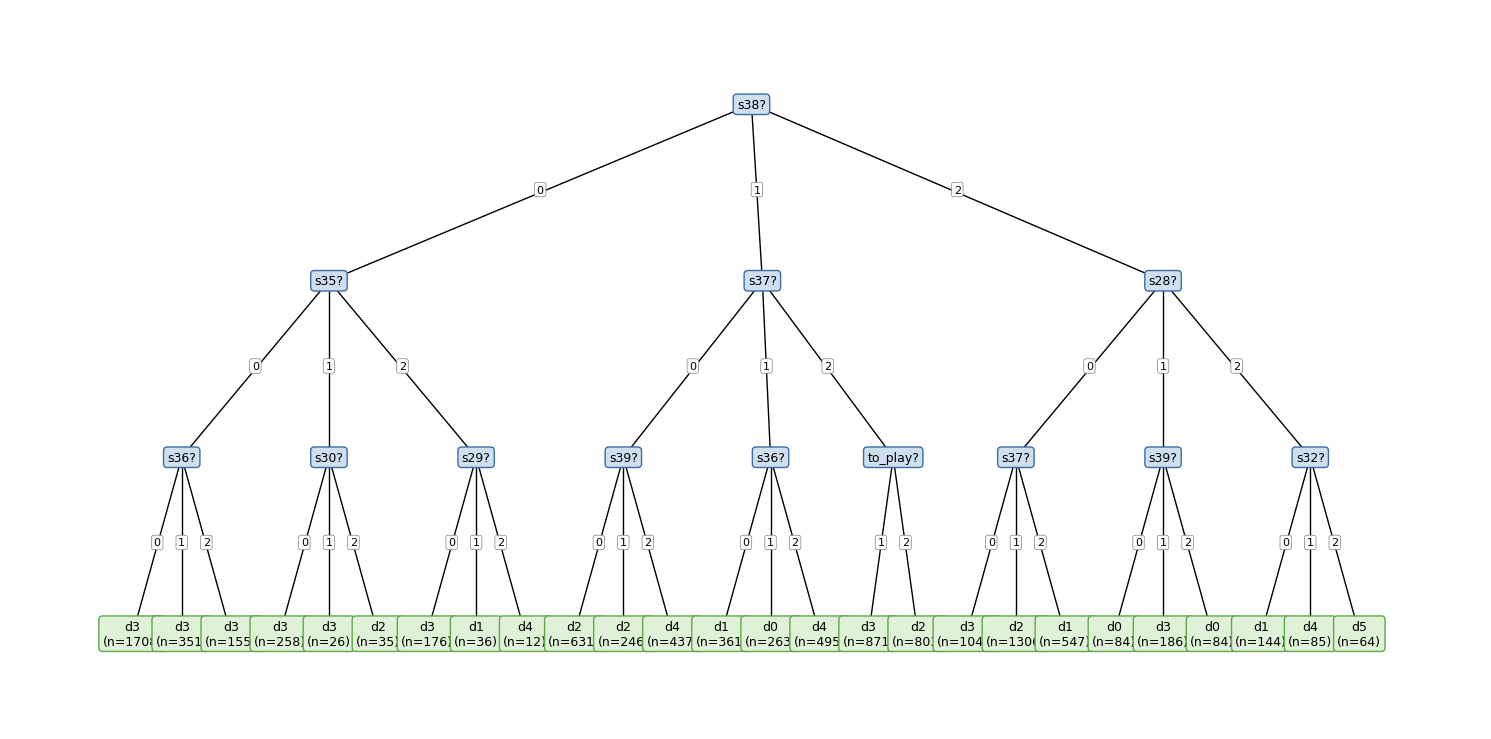

In [68]:
# Adaptação do código original para possível execução no notebook
import argparse
import os
import pickle
import random
import sys
import time
import pandas as pd

def main(argv=None):
    parser = argparse.ArgumentParser()
    parser.add_argument("--max-depth", type=int, default=None)
    parser.add_argument("--sweep", action="store_true")
    parser.add_argument("--vs-random", type=int, default=0)
    parser.add_argument("--vs-mcts", type=int, default=0)
    parser.add_argument("--save", default=TREE_PATH)

    if "CODES_DIR" in globals():
        base_codes_dir = str(CODES_DIR)
    elif "codes_path" in globals():
        base_codes_dir = str(codes_path)
    else:
        candidate = os.path.join(os.getcwd(), "codes")
        base_codes_dir = candidate if os.path.isdir(candidate) else os.getcwd()

    parser.add_argument("--out-dir", default=os.path.join(base_codes_dir, "content"))

    if argv is None and "ipykernel" in sys.modules:
        args, _ = parser.parse_known_args()
    else:
        args = parser.parse_args(argv)

    os.makedirs(args.out_dir, exist_ok=True)

    print("=== ID3 over PopOut dataset ===")
    if not os.path.exists(DATASET_PATH):
        print(f"ERROR: dataset not found at {DATASET_PATH}")
        return 1

    if args.sweep:
        print("\n--- max_depth sweep ---")
        rows = sweep_max_depth()
        best_d, best_r = max(rows, key=lambda kv: kv[1]["test_accuracy"])
        print(f"\nBest max_depth: {best_d}  (acc_te={best_r['test_accuracy']:.3f})")
        result = best_r
    else:
        print(f"\n--- training with max_depth={args.max_depth} ---")
        result = train(max_depth=args.max_depth)
        print(f"  train_accuracy = {result['train_accuracy']:.3f}")
        print(f"  test_accuracy  = {result['test_accuracy']:.3f}")
        print(f"  leaves={result['size']['leaves']} depth={result['size']['depth']}")
        print(f"  train_time={result['train_time_s']:.2f}s")

    tree = result["tree"]
    with open(args.save, "wb") as f:
        pickle.dump(tree, f)
    print(f"\n[saved] {args.save}")

    try:
        trunc = _truncate_tree(tree, max_depth=3)
        fig = render_tree_matplotlib(trunc, figsize=(16, 8))
        out_png = os.path.join(args.out_dir, "popout_tree_top3.png")
        fig.savefig(out_png, dpi=120, bbox_inches="tight")
        print(f"[saved] {out_png}")
    except Exception as e:
        print(f"[warn] matplotlib failed: {e}")

    if args.vs_random > 0:
        print(f"\n--- Tree vs Random ({args.vs_random} games) ---")
        r = play_match(lambda: tree_strategy(tree),
                       lambda: random_strategy(random.Random(0)),
                       n_games=args.vs_random)
        print(f"  Tree {r['wins_a']} - {r['wins_b']} Random  (d={r['draws']})  "
              f"| t/move tree={r['avg_time_a']*1e6:.0f}us "
              f"random={r['avg_time_b']*1e6:.0f}us")

    if args.vs_mcts > 0:
        print(f"\n--- Tree vs MCTS-Medium ({args.vs_mcts} games) ---")
        r = play_match(
            lambda: tree_strategy(tree),
            lambda: mcts_strategy(n_simulations=200, rollout="heuristic_win",
                                  tactical_root=True, rng=random.Random(99)),
            n_games=args.vs_mcts,
        )
        print(f"  Tree {r['wins_a']} - {r['wins_b']} MCTS  (d={r['draws']})  "
              f"| t/move tree={r['avg_time_a']*1e6:.0f}us "
              f"mcts={r['avg_time_b']*1e3:.0f}ms")
    return 0


if "ipykernel" in sys.modules:
    main([])
elif __name__ == "__main__":
    sys.exit(main())

#### **4.2.1. Interpretação de Resultados**
+

### **5. Implementação do Jogo**
A implementação do jogo PopOut, que está contida no ficheiro `game.py`, foi realizada para a linha de comandos (CLI), desenvolvida como base funcional do projeto. A versão CLI permitiu validar de forma incremental as regras do jogo, testar os diferentes modos de execução (*humano vs. humano*, *humano vs. computador* e *computador vs. computador*) e garantir a integração correta com os algoritmos implementados.

Em paralelo, foi também desenvolvida uma versão com interface gráfica (GUI), orientada para uma interação mais intuitiva e visualmente mais acessível. O código e os detalhes de implementação da GUI serão apresentados em *anexo* no final do notebook.

Importações e essenciais:

In [58]:
# Adaptação do código original para possível execução no notebook
import os
import random
from pathlib import Path

from popout import (
    COLS, EMPTY, Move, P1, P2, State,
    apply_move, can_claim_repetition_draw, initial_state, legal_moves, render,
)

if "__file__" in globals():
    BASE_DIR = Path(__file__).resolve().parent
else:
    cwd = Path.cwd()
    BASE_DIR = cwd / "codes" if (cwd / "codes").exists() else cwd

TREE_PATH = str(BASE_DIR / "decision_tree.pkl")

EASY = (100, "random", False)
MEDIUM = (400, "heuristic_win", True)
HARD = (800, "heuristic_win", True)


HELP_TEXT = """\
Commands:
  0..6           drop in column (shortcut)
  d <col>        explicit drop  (e.g. d 3)
  p <col>        pop            (e.g. p 0)
  draw           claim draw by triple repetition (when applicable)
  q | quit       resign
  ? | help       show this help
"""


class ParseError(Exception):
    pass

A função `format_state` converte o estado atual do jogo num texto para o terminal.

In [59]:
def format_state(state):
    header = " " + "".join(str(c) for c in range(COLS))
    body = "\n".join(" " + line for line in render(state.board).split("\n"))
    glyph = {P1: "X", P2: "O"}
    if state.winner is None:
        footer = f"P{state.player_to_move} ({glyph[state.player_to_move]}) to move."
    elif state.winner == "draw":
        footer = "Draw."
    else:
        footer = f"P{state.winner} ({glyph[state.winner]}) wins!"
    return f"{header}\n{body}\n{footer}"

A função `parse_human_input` interpreta o comando inserido pelo jogador no terminal e transforma-o numa ação válida.

In [60]:
def parse_human_input(text, state):
    t = text.strip().lower()
    if t == "":
        raise ParseError("Empty input. Type '?' for help.")
    if t in ("q", "quit"):
        return "resign"
    if t == "draw":
        if can_claim_repetition_draw(state):
            return "draw"
        raise ParseError("Triple repetition not reached -- cannot claim draw.")
    if t in ("?", "help"):
        raise ParseError(HELP_TEXT)
    if len(t) == 1 and t.isdigit():
        return Move(int(t), "drop")
    parts = t.split()
    if len(parts) == 2 and parts[0] in ("d", "drop", "p", "pop"):
        if not parts[1].isdigit():
            raise ParseError(f"Column is not a number: {parts[1]!r}.")
        col = int(parts[1])
        if not 0 <= col < COLS:
            raise ParseError(f"Column out of [0,{COLS-1}]: {col}.")
        kind = "drop" if parts[0] in ("d", "drop") else "pop"
        return Move(col, kind)
    raise ParseError(f"Invalid input: {text!r}. Type '?' for help.")

A função `human_strategy` controla a vez do jogador humano, interpretando e executando a jogada.

In [61]:
def human_strategy(state, input_fn=input, output_fn=print):
    while True:
        try:
            raw = input_fn(f"P{state.player_to_move}> ")
        except EOFError:
            return "resign"
        try:
            decision = parse_human_input(raw, state)
        except ParseError as exc:
            output_fn(str(exc))
            continue
        if isinstance(decision, str):
            return decision
        if decision not in legal_moves(state):
            output_fn(f"Illegal move: {decision}. Try another.")
            continue
        return decision

A função `random_stategy` cria uma estratégia automática que escolhe aleatoriamente para realizar jogadas.

A função `scripted_strategy` cria uma estratégia que joga uma sequência pré-definida de decisões.

In [62]:
def random_strategy(rng=None):
    if rng is None:
        rng = random.Random()

    def strat(state):
        moves = legal_moves(state)
        if not moves:
            return "resign"
        return rng.choice(moves)

    return strat

def scripted_strategy(decisions):
    it = iter(decisions)

    def strat(state):
        return next(it)

    return strat

A função `play_game` executa então a partida completa entre as duas estratégias escolhidas inicialmente pelo humano, alternando turnos até haver vencedor, empate ou desistência.

In [63]:
def play_game(p1, p2, on_render=print, max_turns=300, show_intermediate=True):
    state = initial_state()
    strategies = {P1: p1, P2: p2}
    if show_intermediate:
        on_render(format_state(state))

    turns = 0
    while state.winner is None:
        if turns >= max_turns:
            return State(
                board=state.board,
                player_to_move=state.player_to_move,
                history_counts=state.history_counts,
                last_move=state.last_move,
                winner="draw",
            )
        mover = state.player_to_move
        decision = strategies[mover](state)

        if decision == "resign":
            other = 3 - mover
            return State(
                board=state.board,
                player_to_move=state.player_to_move,
                history_counts=state.history_counts,
                last_move=state.last_move,
                winner=other,
            )
        if decision == "draw":
            return State(
                board=state.board,
                player_to_move=state.player_to_move,
                history_counts=state.history_counts,
                last_move=state.last_move,
                winner="draw",
            )

        state = apply_move(state, decision)
        turns += 1
        if show_intermediate:
            on_render(format_state(state))

    return state

A função `_announce` devolve uma mensagem de feedback no CLI caso a estratégia seja independente de humanos.

A função `_make_mcts` é um construtor do MCTS que se adapta à dificuldade pedida pelo jogador humano (alterando os parâmetros *n_sims*, *rollout* e *tactical_root*). 

A função `_make_tree` carrega o modelo da árvore de decisão e converte-o numa estratégia jogável com `tree_strategy`.

A função `_build_modes` constrói a lista de modos de jogo disponíveis no menu (*humano vs. humano*, *humano vs. MCTS*, *MCTS vs. MCTS*, etc.).

A função `_print_menu` imprime o menu de escolha no terminal.

A função `_read_mode_choice` lê e valida a escolha do utilizador no menu.

In [64]:
def _announce(strat, label):
    def w(state):
        print(f"[{label} thinking...]", flush=True)
        return strat(state)
    return w

def _make_mcts(preset, label, seed=None):
    from mcts import mcts_strategy
    n_sims, rollout, tactical = preset
    rng = random.Random(seed)
    strat = mcts_strategy(n_simulations=n_sims, rollout=rollout,
                          tactical_root=tactical, rng=rng)
    return _announce(strat, label)

def _make_tree():
    import pickle
    from decision_tree_builder import tree_strategy
    with open(TREE_PATH, "rb") as f:
        tree = pickle.load(f)
    return tree_strategy(tree)

def _build_modes():
    modes = [
        ("Human vs Human",
         lambda: (human_strategy, human_strategy)),
        ("Human vs MCTS -- Easy",
         lambda: (human_strategy, _make_mcts(EASY, "MCTS-Easy"))),
        ("Human vs MCTS -- Medium",
         lambda: (human_strategy, _make_mcts(MEDIUM, "MCTS-Medium"))),
        ("Human vs MCTS -- Hard",
         lambda: (human_strategy, _make_mcts(HARD, "MCTS-Hard"))),
        ("MCTS vs MCTS",
         lambda: (_make_mcts(MEDIUM, "MCTS-1"),
                  _make_mcts(MEDIUM, "MCTS-2", seed=99))),
    ]
    if os.path.exists(TREE_PATH):
        modes.extend([
            ("Human vs Tree (ID3)",
             lambda: (human_strategy, _make_tree())),
            ("MCTS vs Tree (CvC, 2 algos)",
             lambda: (_make_mcts(MEDIUM, "MCTS"), _make_tree())),
        ])
    return modes

def _print_menu(modes):
    print("\nPopOut CLI -- choose mode:")
    for i, (label, _) in enumerate(modes):
        print(f"  {i+1}) {label}")
    print("  q) quit")

def _read_mode_choice(modes):
    while True:
        try:
            raw = input("Mode> ").strip().lower()
        except EOFError:
            return None
        if raw in ("q", "quit", "exit"):
            return None
        if raw.isdigit():
            idx = int(raw) - 1
            if 0 <= idx < len(modes):
                return idx
        print(f"Invalid choice. Pick 1-{len(modes)} or 'q'.")


In [65]:
# Adaptação do código original para possível execução no notebook
def main():
    modes = _build_modes()
    if not os.path.exists(TREE_PATH):
        print("(decision_tree.pkl not found - Tree modes unavailable. "
              "Run: python train_tree.py --sweep)")
    while True:
        _print_menu(modes)
        idx = _read_mode_choice(modes)
        if idx is None:
            return
        label, factory = modes[idx]
        print(f"\n=== {label} ===")
        print(HELP_TEXT)
        p1, p2 = factory()
        final = play_game(p1, p2)
        print(format_state(final))
        try:
            again = input("\nPlay again? [y/N] ").strip().lower()
        except EOFError:
            return
        if again not in ("y", "yes"):
            return


if __name__ == "__main__":
    main()


PopOut CLI -- choose mode:
  1) Human vs Human
  2) Human vs MCTS -- Easy
  3) Human vs MCTS -- Medium
  4) Human vs MCTS -- Hard
  5) MCTS vs MCTS
  6) Human vs Tree (ID3)
  7) MCTS vs Tree (CvC, 2 algos)
  q) quit


---
### **6. Discussão Crítica de Resultados**

Para que a conclusão da interpretação dos resultados se tornasse mais intuitiva, foi criado o ficheiro `evaluation.py` que apresenta uma matriz de win-rate *(qualidade de jogo)*, uma curva relativamente à aprendizagem da árvore *(capacidade de generalização)*, uma análise relativa à profundidade e relações temporais. A comparação é feita entre a aleatoriedade, MCTS-E (MCTS aleatório para $N$=100), MCTS-M (MCTS com heurística tática para $N$=200) e Árvore de Decisão.

Importações e funções auxiliares:


In [95]:
# Adaptação do código original para possível execução no notebook
import argparse
import math
import os
import pickle
import random
import sys
import time
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from game import play_game, random_strategy
from decision_tree_builder import (
    accuracy, id3, predict_batch, tree_size, tree_strategy,
)
from popout import P1, P2
from mcts import mcts_strategy

if "CODES_DIR" in globals():
    _codes_dir = Path(CODES_DIR)
elif "codes_path" in globals():
    _codes_dir = Path(codes_path)
else:
    _cwd = Path.cwd()
    _codes_dir = _cwd / "codes" if (_cwd / "codes").exists() else _cwd

CODES_DIR = str(_codes_dir)
DATASET_PATH = str(_codes_dir / "popout_dataset.csv")
TREE_PATH = str(_codes_dir / "decision_tree.pkl")
CONTENT_DIR = str(_codes_dir / "content")
os.makedirs(CONTENT_DIR, exist_ok=True)


def factory_random(seed=999):
    return lambda: random_strategy(random.Random(seed))


def factory_mcts(N, rollout="random", tactical=False, seed=0):
    return lambda: mcts_strategy(
        n_simulations=N, rollout=rollout, tactical_root=tactical,
        rng=random.Random(seed),
    )


def factory_tree(tree):
    return lambda: tree_strategy(tree)


def time_strat(strat):
    times = []

    def w(state):
        t0 = time.perf_counter()
        m = strat(state)
        times.append(time.perf_counter() - t0)
        return m

    w._times = times
    return w


class CellResult:
    def __init__(self, label_a, label_b, wins_a, wins_b, draws,
                 avg_time_a, avg_time_b, n_games):
        self.label_a = label_a
        self.label_b = label_b
        self.wins_a = wins_a
        self.wins_b = wins_b
        self.draws = draws
        self.avg_time_a = avg_time_a
        self.avg_time_b = avg_time_b
        self.n_games = n_games


def run_match(fa, fb, label_a, label_b, n_games=4, max_turns=200):
    wa = 0
    wb = 0
    d = 0
    ta_all, tb_all = [], []
    for g in range(n_games):
        if g % 2 == 0:
            sa = time_strat(fa())
            sb = time_strat(fb())
            p1, p2, ap = sa, sb, P1
        else:
            sb = time_strat(fb())
            sa = time_strat(fa())
            p1, p2, ap = sb, sa, P2
        f = play_game(p1, p2, on_render=lambda _: None,
                      show_intermediate=False, max_turns=max_turns)
        ta_all.extend(sa._times)
        tb_all.extend(sb._times)
        if f.winner == ap:
            wa += 1
        elif f.winner == "draw":
            d += 1
        else:
            wb += 1
    return CellResult(
        label_a=label_a, label_b=label_b,
        wins_a=wa, wins_b=wb, draws=d,
        avg_time_a=sum(ta_all) / max(1, len(ta_all)),
        avg_time_b=sum(tb_all) / max(1, len(tb_all)),
        n_games=n_games,
    )


**Matriz de Win-Rate**

A matriz de win-rate mede, para cada par de estratégias, a fração de pontos conquistados (vitória = 1 pt, empate = 0,5 pt). São corridos **4 jogos por célula**, alternando o jogador inicial para mitigar o viés de primeira jogada.

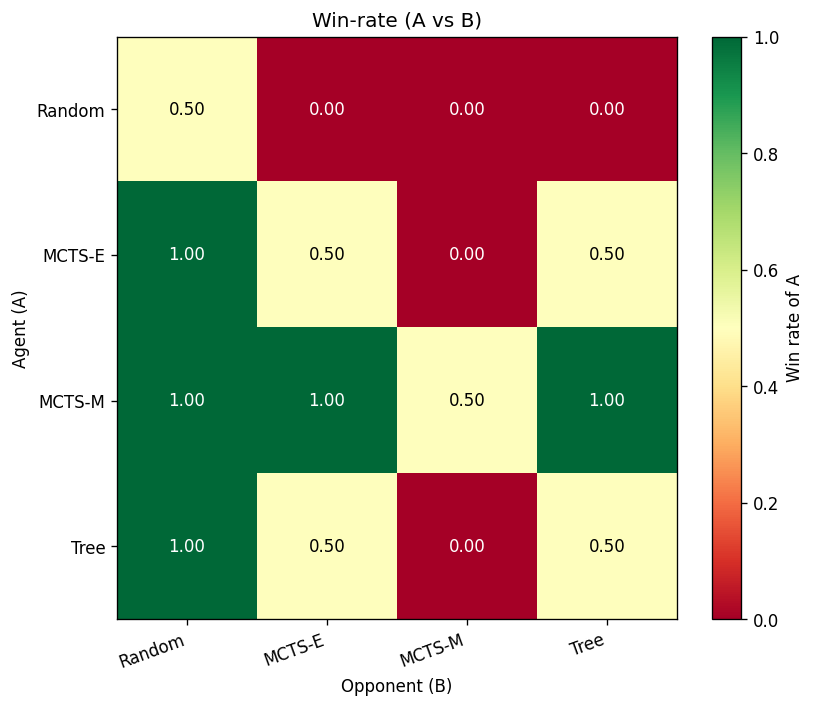

In [92]:
def win_rate_matrix(agents, n_games=4, max_turns=200):
    labels = list(agents.keys())
    n = len(labels)
    matrix = np.zeros((n, n))
    times = {l: [] for l in labels}

    for i, la in enumerate(labels):
        for j, lb in enumerate(labels):
            fa = agents[la]
            fb = agents[lb]
            print(f"  {la:>10} vs {lb:<10}", end=" ", flush=True)
            r = run_match(fa, fb, la, lb, n_games=n_games, max_turns=max_turns)
            matrix[i, j] = (r.wins_a + 0.5 * r.draws) / r.n_games
            print(f"-> {r.wins_a}-{r.wins_b}-{r.draws}  "
                  f"(t/move A={r.avg_time_a*1e3:.1f}ms B={r.avg_time_b*1e3:.1f}ms)",
                  flush=True)
            times[la].append(r.avg_time_a)
            times[lb].append(r.avg_time_b)

    avg_times = {l: float(np.mean(times[l])) if times[l] else 0.0 for l in labels}
    return labels, matrix, avg_times

def chart_winrate_heatmap(labels, matrix, out_path):
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Opponent (B)")
    ax.set_ylabel("Agent (A)")
    ax.set_title("Win-rate (A vs B) -- 0=B always, 1=A always")
    for i in range(len(labels)):
        for j in range(len(labels)):
            color = "black" if 0.3 <= matrix[i, j] <= 0.7 else "white"
            ax.text(j, i, f"{matrix[i,j]:.2f}", ha="center", va="center",
                    color=color, fontsize=10)
    fig.colorbar(im, ax=ax, label="Win rate of A")
    fig.tight_layout()
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close(fig)

# ── Visualização ───────────────────────────────────────
from IPython.display import display, Image as IPyImage
display(IPyImage(filename=str(_wm_path), width=700))

Com o apoio da matriz acima representada é possível verificar que:
- MCTS-M domina a matriz, vencendo a todos os seus adversários. A combinação entre $N$=200, *heuristic_win* e *tactical_root=True* confere uma grande vantagem estratégica em relação aos outros agentes;
- MCTS-E supera o Random, mas perde todos os jogos com MCTS-M, confirmando que o *rollout* heurístico e a componente tática são efetivamente relevantes para o desempenho;
- A Tree supera o Random, tendo um desempenho idêntico ao do MCTS-E;
- o Random obtêm os piores resultados, sendo a estratégia menos favorável à vitória.

**Conclusão:** MCTS-M **>** MCTS-E ~ Tree **>** Random, pelo que é relevante considerar a qualidade dos *rollouts* e o número de simulações.

**Análise da curva de aprendizagem:**

| Fração treino | Nº exemplos | Test acc |
|:-------------:|:-----------:|:--------:|
| 20% | ≈ 2 000 | 0.18 |
| 40% | ≈ 4 100 | 0.20 |
| 60% | ≈ 6 200 | 0.22 |
| 80% | ≈ 8 300 | 0.24 |

- A *accuracy* de teste cresce de forma **lenta e quase linear** com mais dados: de 0,18 com 2 000 exemplos para 0,24 com 8 300. O ganho marginal é muito pequeno por cada duplicação do dataset.
- A *accuracy* máxima alcançada (~24%) é **modesta**. Isto explica-se pela natureza do problema: o PopOut tem um espaço de estados muito grande, e o dataset atual — gerado a partir de partidas de MCTS médio — cobre apenas uma fração desse espaço, criando um enviesamento de distribuição.
- A curva não mostra sinais de saturação ao longo do intervalo testado, sugerindo que **mais dados continuariam a melhorar** ligeiramente o desempenho; porém, o gargalo está na diversidade dos estados e não apenas na quantidade de exemplos.
- Para melhorar significativamente seria necessário ampliar o dataset com partidas geradas por agentes de diferentes forças (incluindo jogos aleatórios, MCTS com vários N, e humanos), cobrindo de forma mais uniforme o espaço de estados.


#### **6.3. Sensibilidade à Profundidade da Árvore (`max_depth`)**

O hiperparâmetro `max_depth` controla a complexidade da árvore ID3. O gráfico abaixo mostra a *accuracy* de treino e de teste para diferentes valores de `max_depth` (3, 5, 8, 10 e sem limite).


Gráfico já existente — a carregar imagem guardada.


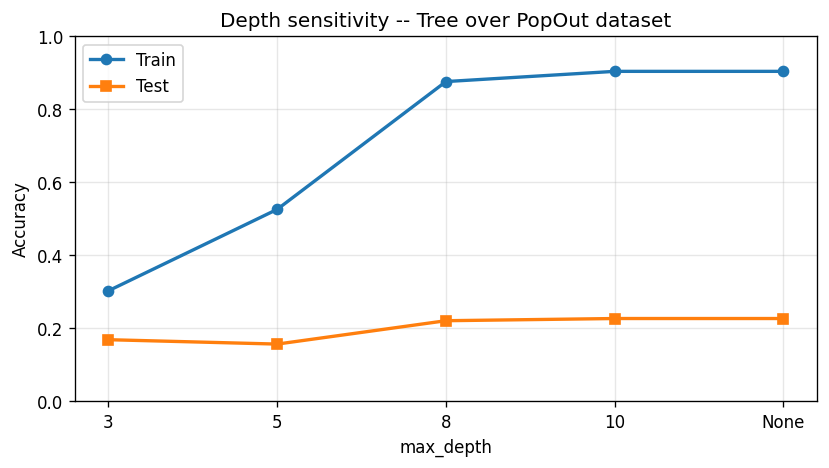

Figura 3 — Sensibilidade ao max_depth (Train vs Test accuracy)


In [74]:
# ── Sensibilidade à profundidade ───────────────────────────────────────────────
from IPython.display import display, Image as IPyImage

_ds_path = _CONTENT_DIR / "tree_depth_sensitivity.png"

if not _ds_path.exists():
    _CONTENT_DIR.mkdir(parents=True, exist_ok=True)
    chart_depth_sensitivity(str(_ds_path))
    print("Gráfico gerado e guardado.")
else:
    print("Gráfico já existente — a carregar imagem guardada.")

display(IPyImage(filename=str(_ds_path), width=700))
print("Figura 3 — Sensibilidade ao max_depth (Train vs Test accuracy)")


**Análise da sensibilidade à profundidade:**

| max_depth | Train acc | Test acc |
|:---------:|:---------:|:--------:|
| 3 | 0.303 | 0.169 |
| 5 | 0.526 | 0.157 |
| 8 | 0.876 | 0.221 |
| 10 | 0.904 | 0.227 |
| None | 0.904 | 0.227 |

- Com `max_depth=3` a árvore é **demasiado simples** (underfitting): a *accuracy* de treino e de teste são ambas baixas, o modelo não consegue representar a estrutura do problema.
- Com `max_depth=5` a *accuracy* de treino sobe mas a de **teste desce ligeiramente**, sinal de que algumas ramificações desnecessárias prejudicam a generalização.
- A partir de `max_depth=8–10` as duas métricas estabilizam: a árvore aprendeu tudo o que o dataset permite aprender.
- A ausência de limite (`None`) produz o mesmo resultado que `max_depth=10`, confirmando que os dados disponíveis não justificam uma profundidade superior.
- O gap pronunciado entre treino (~90%) e teste (~23%) indica **overfitting ao dataset**: a árvore memoriza padrões específicos dos exemplos de treino que não generalizam bem para novos estados de jogo. Isto é expectável num problema de jogo com espaço de estados vasto e dataset limitado.


#### **6.4. Escalabilidade Temporal do MCTS**

Uma dimensão prática crucial do MCTS é o seu custo computacional: o número de simulações N controla diretamente o trade-off qualidade/velocidade. O gráfico seguinte mostra como o tempo médio por jogada cresce com N.


Gráfico já existente — a carregar imagem guardada.


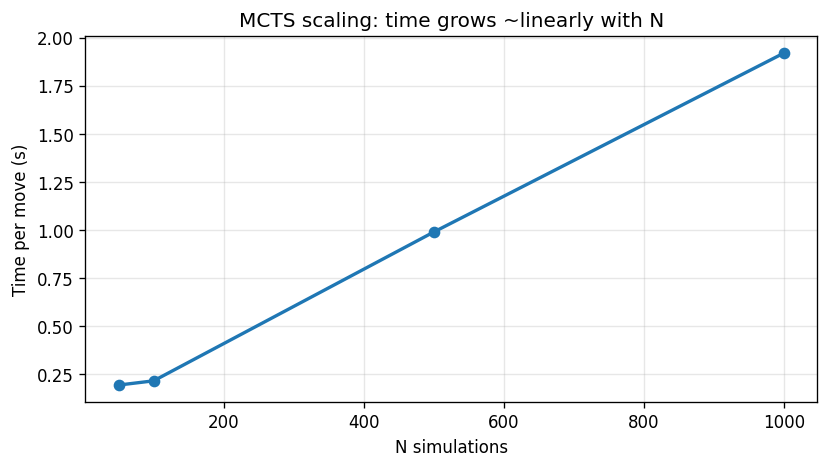

Figura 4 — Tempo por jogada do MCTS em função de N simulações


In [75]:
# ── Escalabilidade temporal do MCTS ───────────────────────────────────────────
from IPython.display import display, Image as IPyImage

_mt_path = _CONTENT_DIR / "mcts_time_vs_n.png"

if not _mt_path.exists():
    _CONTENT_DIR.mkdir(parents=True, exist_ok=True)
    chart_mcts_time_vs_n(str(_mt_path))
    print("Gráfico gerado e guardado.")
else:
    print("Gráfico já existente — a carregar imagem guardada.")

display(IPyImage(filename=str(_mt_path), width=700))
print("Figura 4 — Tempo por jogada do MCTS em função de N simulações")


**Análise da escalabilidade temporal:**

| N simulações | Tempo/jogada |
|:------------:|:------------:|
| 50 | ≈ 194 ms |
| 100 | ≈ 216 ms |
| 500 | ≈ 990 ms |
| 1000 | ≈ 1921 ms |

- O tempo cresce **aproximadamente de forma linear** com N, como esperado pela estrutura do algoritmo: cada simulação percorre a árvore de cima a baixo e executa um rollout completo.
- A pequena irregularidade entre N=50 e N=100 resulta de overheads de inicialização do objeto de jogo e de variabilidade do sistema.
- Para uso em tempo real (e.g., jogos interativos humano vs. computador), **N=100–200** oferece um equilíbrio aceitável: respostas em < 0,25 s com qualidade de jogo razoável.
- Para jogos computador vs. computador e geração de dataset, **N=200–500** é preferível, uma vez que o tempo total de geração é aceitável e a qualidade das partidas é superior.

#### **6.5. Síntese Crítica**

| Dimensão | Random | MCTS-E (N=100) | MCTS-M (N=200) | Tree (ID3) |
|----------|:------:|:--------------:|:--------------:|:----------:|
| Qualidade de jogo | ★☆☆☆ | ★★★☆ | ★★★★ | ★★☆☆ |
| Tempo por jogada | < 0,1 ms | ≈ 216 ms | ≈ 990 ms | < 0,1 ms |
| Interpretabilidade | N/A | Baixa | Baixa | **Alta** |
| Necessidade de dados | Nenhuma | Nenhuma | Nenhuma | **Alta** |

- O **MCTS** é a abordagem mais forte em qualidade de jogo — não precisa de dados, adapta-se em tempo real e melhora com mais simulações, mas tem custo computacional proporcional a N.
- A **Árvore ID3** é competitiva a baixo custo computacional, extremamente interpretável (o caminho de decisão é auditável) e adequada para cenários com restrições de tempo de resposta. A sua principal limitação é a dependência da qualidade e diversidade do dataset.
- A **estratégia aleatória** serve apenas como *baseline*: o seu único papel é quantificar o ganho das abordagens informadas.
- O projeto demonstra que **a combinação MCTS + ID3** é complementar: o MCTS gera dados de qualidade que a árvore aprende a imitar, obtendo um agente rápido e razoavelmente competente — um padrão de *knowledge distillation* aplicado a jogos.


---
### **7. Conclusão**

Este projeto implementou e avaliou duas abordagens de Inteligência Artificial aplicadas ao jogo PopOut: o algoritmo Monte Carlo Tree Search (MCTS) com UCT e o algoritmo ID3 para árvores de decisão.

O MCTS revelou-se uma solução eficaz para jogos como o PopOut. A variante com rollout *heuristic_win e *tactical_root=True* (MCTS-M) dominou todas as comparações, demonstrando que guiar as simulações com conhecimento produz vantagem nos ganhos. A escalabilidade linear com o número de simulações $N$ torna o MCTS facilmente adaptável à gestão de tempo.

---
### **8. Referências Bibliográficas**

Trovão, J. P. (2017, 11 de outubro). Exploration vs exploitation. TGA. https://www.tga.pt/ponto-tga/estrategia/exploration-vs-exploitation/

GeeksforGeeks. (2025, December 3). Monte Carlo Tree Search (MCTS) in machine learning. GeeksforGeeks. https://www.geeksforgeeks.org/machine-learning/monte-carlo-tree-search-mcts-in-machine-learning/

GeeksforGeeks. (2025, August 6). Iterative Dichotomiser 3 (ID3) algorithm from scratch. GeeksforGeeks. https://www.geeksforgeeks.org/iterative-dichotomiser-3-id3-algorithm-from-scratch/


---
### ANEXO I - Interface Gráfica (GUI)

In [97]:
# Adaptação do código original para possível execução no notebook
import os
import sys
import threading
import time
from pathlib import Path

os.environ.setdefault("PYGAME_HIDE_SUPPORT_PROMPT", "1")

import pygame  # noqa: E402

from popout import (  # noqa: E402
    COLS, EMPTY, P1, P2, ROWS, Move,
    apply_move, initial_state, legal_moves,
)


CELL = 90
PAD = 12
HEADER = 70
FOOTER = 70
STATUS = 50
WIDTH = COLS * CELL + 2 * PAD
HEIGHT = STATUS + HEADER + ROWS * CELL + FOOTER + PAD

BG = (24, 36, 64)
HOLE = (16, 24, 44)
P1_COLOR = (235, 84, 80)
P2_COLOR = (255, 207, 64)
TEXT = (240, 240, 240)
MUTED = (140, 150, 170)
ACCENT = (90, 180, 255)
WIN_HIGHLIGHT = (60, 220, 120)
DROP_BTN = (60, 80, 130)
POP_BTN_OK = (180, 80, 80)
POP_BTN_DISABLED = (60, 60, 80)
HOVER = (110, 140, 200)


def _resolve_codes_dir():
    if "CODES_DIR" in globals():
        return Path(str(CODES_DIR))
    if "codes_path" in globals():
        return Path(str(codes_path))
    if "__file__" in globals():
        return Path(__file__).resolve().parent
    cwd = Path.cwd()
    return cwd / "codes" if (cwd / "codes").exists() else cwd


CODES_BASE = _resolve_codes_dir()
TREE_PATH = str(CODES_BASE / "decision_tree.pkl")


def col_x(c):
    return PAD + c * CELL


def cell_rect(r, c):
    return pygame.Rect(col_x(c), STATUS + HEADER + r * CELL, CELL, CELL)


def drop_btn_rect(c):
    return pygame.Rect(col_x(c) + 6, STATUS + 6, CELL - 12, HEADER - 12)


def pop_btn_rect(c):
    y = STATUS + HEADER + ROWS * CELL + 6
    return pygame.Rect(col_x(c) + 6, y, CELL - 12, FOOTER - 12)


def draw_board(screen, font_small, state, mouse_pos, busy, winning_cells=None):
    screen.fill((10, 14, 28))
    winning_cells = set(winning_cells or [])

    legals = set(legal_moves(state)) if state.winner is None and not busy else set()
    legal_drop_cols = {m.column for m in legals if m.kind == "drop"}
    legal_pop_cols = {m.column for m in legals if m.kind == "pop"}

    for c in range(COLS):
        rect = drop_btn_rect(c)
        is_legal = c in legal_drop_cols
        is_hover = is_legal and rect.collidepoint(mouse_pos)
        color = HOVER if is_hover else (DROP_BTN if is_legal else POP_BTN_DISABLED)
        pygame.draw.rect(screen, color, rect, border_radius=8)
        label = font_small.render("Drop", True, TEXT if is_legal else MUTED)
        screen.blit(label, label.get_rect(center=rect.center))

    board_rect = pygame.Rect(PAD, STATUS + HEADER, COLS * CELL, ROWS * CELL)
    pygame.draw.rect(screen, BG, board_rect, border_radius=12)

    for r in range(ROWS):
        for c in range(COLS):
            cx = col_x(c) + CELL // 2
            cy = STATUS + HEADER + r * CELL + CELL // 2
            radius = CELL // 2 - 8
            v = int(state.board[r, c])
            if v == EMPTY:
                pygame.draw.circle(screen, HOLE, (cx, cy), radius)
            else:
                fill = P1_COLOR if v == P1 else P2_COLOR
                pygame.draw.circle(screen, fill, (cx, cy), radius)
                if (r, c) in winning_cells:
                    pygame.draw.circle(screen, WIN_HIGHLIGHT, (cx, cy), radius, width=4)

    for c in range(COLS):
        rect = pop_btn_rect(c)
        is_legal = c in legal_pop_cols
        is_hover = is_legal and rect.collidepoint(mouse_pos)
        color = HOVER if is_hover else (POP_BTN_OK if is_legal else POP_BTN_DISABLED)
        pygame.draw.rect(screen, color, rect, border_radius=8)
        label = font_small.render("Pop", True, TEXT if is_legal else MUTED)
        screen.blit(label, label.get_rect(center=rect.center))


def find_winning_cells(state):
    if state.winner not in (P1, P2):
        return []
    player = state.winner
    dirs = [(0, 1), (1, 0), (1, 1), (1, -1)]
    for r in range(ROWS):
        for c in range(COLS):
            if int(state.board[r, c]) != player:
                continue
            for dr, dc in dirs:
                rr, cc = r + 3 * dr, c + 3 * dc
                if 0 <= rr < ROWS and 0 <= cc < COLS:
                    cells = [(r + i * dr, c + i * dc) for i in range(4)]
                    if all(int(state.board[y, x]) == player for y, x in cells):
                        return cells
    return []


def draw_status(screen, font, state, mode_label, busy):
    bar = pygame.Rect(0, 0, WIDTH, STATUS)
    pygame.draw.rect(screen, (18, 24, 44), bar)
    if state.winner is None:
        glyph_color = P1_COLOR if state.player_to_move == P1 else P2_COLOR
        msg = f"P{state.player_to_move} to move"
        if busy:
            msg += "  -  AI thinking..."
    elif state.winner == "draw":
        glyph_color = MUTED
        msg = "Draw."
    else:
        glyph_color = P1_COLOR if state.winner == P1 else P2_COLOR
        msg = f"P{state.winner} wins!"
    pygame.draw.circle(screen, glyph_color, (24, STATUS // 2), 12)
    text = font.render(msg, True, TEXT)
    screen.blit(text, text.get_rect(midleft=(48, STATUS // 2)))
    mode_text = font.render(mode_label, True, MUTED)
    screen.blit(mode_text, mode_text.get_rect(midright=(WIDTH - 14, STATUS // 2)))


def draw_endgame_card(screen, font_big, font_small, title, subtitle, button_labels,
                      glyph_color):
    margin_x = 20
    box = pygame.Rect(margin_x, 6, WIDTH - 2 * margin_x, STATUS + HEADER - 12)
    card = pygame.Surface((box.width, box.height), pygame.SRCALPHA)
    pygame.draw.rect(card, (30, 36, 60, 235), card.get_rect(), border_radius=14)
    pygame.draw.rect(card, ACCENT, card.get_rect(), width=2, border_radius=14)
    screen.blit(card, box.topleft)

    glyph_cx = box.left + 24
    glyph_cy = box.top + 22
    pygame.draw.circle(screen, glyph_color, (glyph_cx, glyph_cy), 10)
    title_surf = font_big.render(title, True, TEXT)
    screen.blit(title_surf, title_surf.get_rect(midleft=(glyph_cx + 18, glyph_cy)))
    sub_surf = font_small.render(subtitle, True, MUTED)
    screen.blit(sub_surf, sub_surf.get_rect(midleft=(glyph_cx + 18, glyph_cy + 22)))

    buttons = []
    btn_w = 130
    btn_h = 34
    gap = 12
    total = len(button_labels) * btn_w + (len(button_labels) - 1) * gap
    start_x = box.right - total - 14
    btn_y = box.centery - btn_h // 2
    for i, label in enumerate(button_labels):
        rect = pygame.Rect(start_x + i * (btn_w + gap), btn_y, btn_w, btn_h)
        pygame.draw.rect(screen, DROP_BTN, rect, border_radius=8)
        text = font_small.render(label, True, TEXT)
        screen.blit(text, text.get_rect(center=rect.center))
        buttons.append((label, rect))
    return buttons


class StrategyWorker:

    def __init__(self, strategy_factory):
        self._factory = strategy_factory
        self._thread = None
        self._result = None
        self._lock = threading.Lock()

    def start(self, state):
        if self._thread is not None:
            return

        def _run_worker():
            strat = self._factory()
            decision = strat(state)
            with self._lock:
                self._result = decision

        self._result = None
        self._thread = threading.Thread(target=_run_worker, daemon=True)
        self._thread.start()

    def poll(self):
        with self._lock:
            result = self._result
        if result is not None and self._thread is not None and not self._thread.is_alive():
            self._thread = None
            self._result = None
            return result
        return None

    @property
    def busy(self):
        return self._thread is not None and self._thread.is_alive()


def make_mcts_factory(n_simulations, rollout="heuristic_win", tactical=False, seed=None):
    import random as _random
    from mcts import mcts_strategy

    def factory():
        rng = _random.Random(seed)
        return mcts_strategy(
            n_simulations=n_simulations,
            rollout=rollout,
            tactical_root=tactical,
            rng=rng,
        )

    return factory


def make_tree_factory(tree_path):
    import pickle as _pkl
    from decision_tree_builder import tree_strategy

    def factory():
        with open(tree_path, "rb") as f:
            tree = _pkl.load(f)
        return tree_strategy(tree)

    return factory


EASY = (100, "random", False)
MEDIUM = (400, "heuristic_win", True)
HARD = (800, "heuristic_win", True)


def _build_modes():
    modes = [
        ("Human vs Human", lambda: ("human", "human")),
        ("Human vs MCTS -- Easy", lambda: ("human", make_mcts_factory(*EASY))),
        ("Human vs MCTS -- Medium", lambda: ("human", make_mcts_factory(*MEDIUM))),
        ("Human vs MCTS -- Hard", lambda: ("human", make_mcts_factory(*HARD))),
        (
            "MCTS vs MCTS",
            lambda: (make_mcts_factory(*MEDIUM), make_mcts_factory(*MEDIUM, seed=99)),
        ),
    ]

    tree_path = TREE_PATH
    if os.path.exists(tree_path):
        modes.extend([
            ("Human vs Tree", lambda: ("human", make_tree_factory(tree_path))),
            ("MCTS vs Tree", lambda: (make_mcts_factory(*MEDIUM), make_tree_factory(tree_path))),
        ])
    return modes


MODES = _build_modes()


def draw_menu(screen, font_big, font_small, mouse_pos):
    screen.fill((10, 14, 28))
    title = font_big.render("PopOut -- choose mode", True, TEXT)
    screen.blit(title, title.get_rect(center=(WIDTH // 2, 50)))

    n_modes = len(MODES)
    btn_h = 48
    gap = 10
    start_y = 100
    available = HEIGHT - start_y - 60
    if n_modes * btn_h + (n_modes - 1) * gap > available:
        btn_h = max(36, (available - (n_modes - 1) * gap) // n_modes)

    rects = []
    for i, (label, _) in enumerate(MODES):
        rect = pygame.Rect(WIDTH // 2 - 230, start_y + i * (btn_h + gap), 460, btn_h)
        is_hover = rect.collidepoint(mouse_pos)
        color = HOVER if is_hover else DROP_BTN
        pygame.draw.rect(screen, color, rect, border_radius=10)
        text = font_small.render(label, True, TEXT)
        screen.blit(text, text.get_rect(center=rect.center))
        rects.append((label, rect))

    hint = font_small.render(
        "ESC: back to menu  |  R: restart  |  close window: quit", True, MUTED,
    )
    screen.blit(hint, hint.get_rect(center=(WIDTH // 2, HEIGHT - 30)))
    return rects


def run():
    pygame.init()
    pygame.display.set_caption("PopOut -- IA 2025/2026")
    screen = pygame.display.set_mode((WIDTH, HEIGHT))
    clock = pygame.time.Clock()
    font_big = pygame.font.SysFont("Helvetica", 28, bold=True)
    font = pygame.font.SysFont("Helvetica", 22)
    font_small = pygame.font.SysFont("Helvetica", 18)

    in_menu = True
    state = initial_state()
    mode_label = ""
    p1_strat = p2_strat = None
    workers = {P1: None, P2: None}
    score = {P1: 0, P2: 0, "draw": 0}
    last_winner = None
    show_endgame_modal = False
    endgame_time = None
    win_reveal_delay = 1.5

    def reset_game():
        nonlocal state, last_winner, show_endgame_modal, endgame_time
        state = initial_state()
        last_winner = None
        show_endgame_modal = False
        endgame_time = None

    def setup_mode(mode_idx):
        nonlocal p1_strat, p2_strat, mode_label, in_menu, workers
        label, factory_fn = MODES[mode_idx]
        mode_label = label
        p1_factory, p2_factory = factory_fn()
        p1_strat, p2_strat = p1_factory, p2_factory
        workers = {
            P1: None if p1_strat == "human" else StrategyWorker(p1_strat),
            P2: None if p2_strat == "human" else StrategyWorker(p2_strat),
        }
        reset_game()
        in_menu = False

    while True:
        mouse_pos = pygame.mouse.get_pos()

        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                return 0
            if event.type == pygame.KEYDOWN:
                if event.key == pygame.K_ESCAPE:
                    in_menu = True
                    workers = {P1: None, P2: None}
                elif event.key == pygame.K_r and not in_menu:
                    reset_game()
            if in_menu and event.type == pygame.MOUSEBUTTONDOWN:
                rects = draw_menu(screen, font_big, font_small, mouse_pos)
                for i, (_, rect) in enumerate(rects):
                    if rect.collidepoint(event.pos):
                        setup_mode(i)
                        break
                continue
            if not in_menu and event.type == pygame.MOUSEBUTTONDOWN:
                if show_endgame_modal or state.winner is not None:
                    continue
                strat = p1_strat if state.player_to_move == P1 else p2_strat
                if strat != "human":
                    continue
                for c in range(COLS):
                    if drop_btn_rect(c).collidepoint(event.pos):
                        m = Move(c, "drop")
                        if m in legal_moves(state):
                            state = apply_move(state, m)
                            break
                else:
                    for c in range(COLS):
                        if pop_btn_rect(c).collidepoint(event.pos):
                            m = Move(c, "pop")
                            if m in legal_moves(state):
                                state = apply_move(state, m)
                                break

        if in_menu:
            draw_menu(screen, font_big, font_small, mouse_pos)
        else:
            if state.winner is None and not show_endgame_modal:
                worker = workers[state.player_to_move]
                if worker is not None:
                    decision = worker.poll()
                    if decision is not None:
                        if isinstance(decision, Move) and decision in legal_moves(state):
                            state = apply_move(state, decision)
                    elif not worker.busy:
                        worker.start(state)

            busy = any(w is not None and w.busy for w in workers.values())
            wcells = find_winning_cells(state) if state.winner else []
            draw_board(screen, font_small, state, mouse_pos, busy, winning_cells=wcells)
            draw_status(screen, font, state, mode_label, busy)

            if state.winner is not None and last_winner != state.winner:
                score[state.winner] += 1
                last_winner = state.winner
                endgame_time = time.time()

            if (
                state.winner is not None
                and not show_endgame_modal
                and endgame_time is not None
                and time.time() - endgame_time >= win_reveal_delay
            ):
                show_endgame_modal = True

            if show_endgame_modal:
                title_line = "Draw" if state.winner == "draw" else f"P{state.winner} wins!"
                placar = (
                    f"Score: P1 {score[P1]}  -  P2 {score[P2]}  "
                    f"(draws: {score['draw']})"
                )
                glyph_color = MUTED if state.winner == "draw" else (P1_COLOR if state.winner == P1 else P2_COLOR)
                buttons = draw_endgame_card(
                    screen,
                    font_big,
                    font_small,
                    title_line,
                    placar,
                    ["Play again", "Change mode"],
                    glyph_color,
                )
                if pygame.mouse.get_pressed()[0]:
                    px, py = pygame.mouse.get_pos()
                    for label, rect in buttons:
                        if rect.collidepoint(px, py):
                            if label == "Play again":
                                reset_game()
                            else:
                                in_menu = True
                                workers = {P1: None, P2: None}
                            time.sleep(0.15)
                            break

        pygame.display.flip()
        clock.tick(60)


if __name__ == "__main__":
    run()


ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default
